# 와인 품질 예측 모델 개발: 최적화 및 분석 보고서

## 1. 개요
본 노트북은 와인 품질 데이터(`wine_data_homework.csv`)를 분석하여 품질 등급을 예측하는 머신러닝 모델을 개발하는 과정을 담고 있습니다.
과제의 핵심 요구사항인 **'최소한의 피처 사용'**, **'이상치 처리'**, **'MLflow를 활용한 실험 추적'**, 그리고 **'숨겨진 데이터셋에 대한 일반화 성능 확보'**를 목표로 합니다.

### 분석 전략 (Workflow)
데이터 누수(Data Leakage)를 원천 차단하고 모델의 신뢰성을 높이기 위해 다음 워크플로우를 엄격히 준수합니다.
1. **데이터 분리 우선 (Split First):** 전처리 이전에 Train/Test 셋을 분리하여 Test 셋 오염 방지
2. **Train 셋 기반 분석:** 모든 EDA 및 전처리 기준(평균, 분산, 이상치 범위 등)은 오직 Train 셋에서만 도출
3. **비교 분석 및 최적화:** 결측치 처리, 스케일링, 샘플링 등 각 단계에서 다양한 기법을 비교하여 최적의 방법 선택
4. **MLflow 실험 관리:** 하이퍼파라미터 튜닝 및 모델 성능 기록

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import mlflow
import mlflow.sklearn

# 시각화 및 한글 폰트 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rc('font', family='Malgun Gothic') # Windows 환경 (필요시 변경)
plt.rc('axes', unicode_minus=False)
warnings.filterwarnings('ignore')
np.random.seed(42)

# Scikit-learn 및 관련 라이브러리
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, f1_score, accuracy_score, classification_report
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
from collections import Counter

# MLflow 설정 (Ajoupyterhub 환경 고려)
# user_id = "your_id"
# mlflow.set_tracking_uri(f"file:///home/{user_id}/.mlflow")
mlflow.set_tracking_uri("./mlruns") # 로컬 테스트용

## 2. 데이터 로드 및 초기 분리 (Data Loading & Splitting)

**핵심 전략:** 데이터 전처리 전에 **가장 먼저** Train Set과 Test Set을 분리합니다.
- 이는 전처리 과정(스케일링, 결측치 대체 등)에서 Test Set의 정보가 모델에 흘러들어가는 **Data Leakage**를 방지하기 위함입니다.
- 타겟 변수(`quality`)의 분포 불균형을 고려하여 `stratify` 옵션을 사용합니다.


=== 기본 통계 정보 ===

=== Quality 분포 ===
quality
3      19
4     142
5    1214
6    1718
7     747
8     156
9       5
Name: count, dtype: int64

Quality 범위: 3 ~ 9


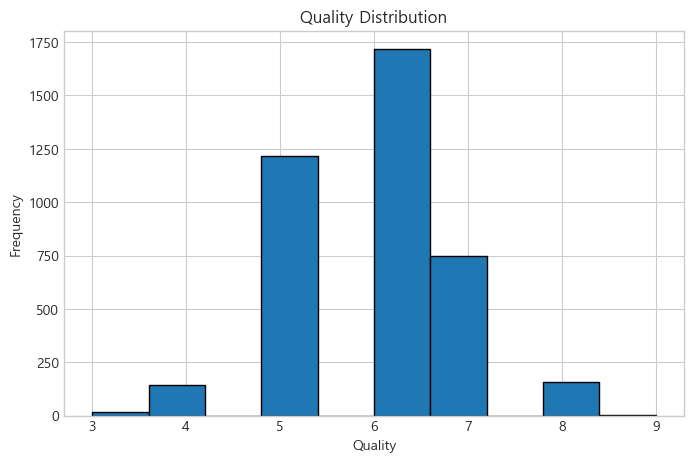

전체 데이터 크기: (4001, 12)
Train 데이터 크기: (3200, 11)
Test 데이터 크기: (801, 11) (최종 평가 전까지 봉인)


In [2]:
# 데이터 로드
df_raw = pd.read_csv('wine_data_homework.csv')
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop('Unnamed: 0', axis=1)

# 기본 통계 정보
print("\n=== 기본 통계 정보 ===")
df_raw.describe()

# 타겟 변수(quality) 분포 확인
print("\n=== Quality 분포 ===")
print(df_raw['quality'].value_counts().sort_index())
print(f"\nQuality 범위: {df_raw['quality'].min()} ~ {df_raw['quality'].max()}")
plt.figure(figsize=(8, 5))
df_raw['quality'].hist(bins=10, edgecolor='black')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.title('Quality Distribution')
plt.show()

# 입력(X)과 타겟(y) 분리
X = df_raw.drop('quality', axis=1)
y = df_raw['quality']

# Train/Test 분리 (8:2 비율, 계층적 샘플링)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"전체 데이터 크기: {df_raw.shape}")
print(f"Train 데이터 크기: {X_train.shape}")
print(f"Test 데이터 크기: {X_test.shape} (최종 평가 전까지 봉인)")

## 3. 탐색적 데이터 분석 (EDA) - Train Set Only

오직 **Train 데이터**만을 사용하여 데이터의 특성을 파악합니다. 여기서 얻은 인사이트를 바탕으로 전처리 전략을 수립합니다.

In [3]:
# 결측치 확인
missing_values = X_train.isnull().sum()
print(missing_values)

if missing_values.sum() > 0:
    print(f"\n총 결측치 개수: {missing_values.sum()}")
    # 결측치 시각화
    plt.figure(figsize=(10, 6))
    missing_values[missing_values > 0].plot(kind='bar')
    plt.title('Missing Values by Column')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()
else:
    print("\n결측치가 없습니다.")
    
print("Train Set 결측치 현황:")
print(missing_values[missing_values > 0])

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
dtype: int64

결측치가 없습니다.
Train Set 결측치 현황:
Series([], dtype: int64)


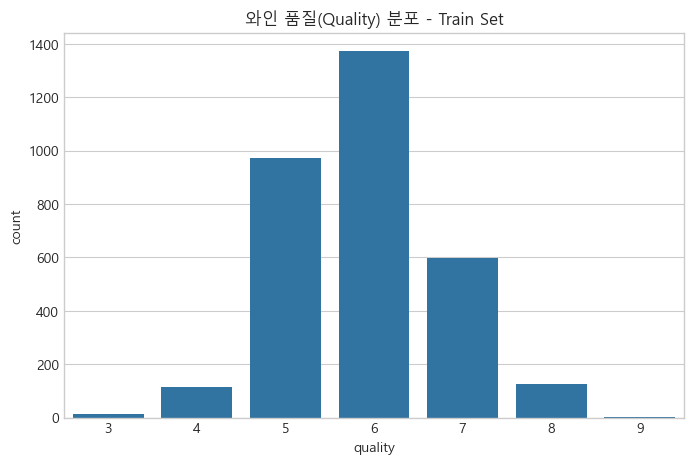

In [4]:
# 타겟 분포 확인
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train)
plt.title("와인 품질(Quality) 분포 - Train Set")
plt.show()

**EDA 결과 및 분석 방향:**
1. **결측치:** 결측치가 없습니다. 모든 피처에 대해 완전한 데이터가 존재합니다.
2. **불균형:** Quality 6, 5 등급이 대다수이며, 3, 4, 8, 9 등급은 데이터가 매우 적습니다. -> **오버샘플링 필요**
3. **스케일:** 피처 간 값의 범위 차이가 큽니다(예: `sulfur dioxide` vs `chlorides`). -> **스케일링 필요**

## 4. 전처리 전략 비교 및 결정 (Preprocessing Strategy)

다양한 전처리 기법을 비교 분석하여 최적의 방법을 선택합니다. 모든 기준은 Train Set에서 학습(`fit`)됩니다.

### 4.1. 결측치 처리 (Imputation)
**현재 데이터셋 상태:** 결측치가 없으므로 별도의 결측치 처리가 필요하지 않습니다.

**참고: 결측치 처리 방법론**
일반적으로 결측치가 있는 경우 다음과 같은 방법을 고려할 수 있습니다:
- `Drop`: 결측치가 포함된 행을 제거. 데이터 손실 발생.
- `Mean/Median Imputation`: 평균/중앙값으로 대체. 데이터 보존 가능.

**결정:** **결측치 없음**
현재 데이터셋에는 결측치가 없으므로, 원본 데이터를 그대로 사용합니다. 아래 코드는 참고용으로 주석 처리합니다.

In [5]:
# 결측치가 없는 경우이므로 주석 처리
# imputer = SimpleImputer(strategy='mean')
# imputer.fit(X_train)
# X_train_filled = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns, index=X_train.index)
# X_test_filled = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

# 결측치가 없으므로 원본 데이터 그대로 사용
X_train_filled = X_train.copy()
X_test_filled = X_test.copy()

### 4.2. 이상치 처리 (Outlier Removal)
과제 요구사항에 따라 이상치를 제거해야 합니다.

**전략:** **IQR (Interquartile Range) 방식**
- `Q1 - 1.5*IQR` 미만 또는 `Q3 + 1.5*IQR` 초과 데이터를 이상치로 정의합니다.
- **주의:** 이상치 제거는 **Train Set에만** 수행합니다. Test Set은 실제 운영 환경을 대변하므로 이상치가 포함되어 있어도 예측을 수행해야 모델의 강건성(Robustness)을 평가할 수 있습니다.

**이상치 시각화 (처리 전)**

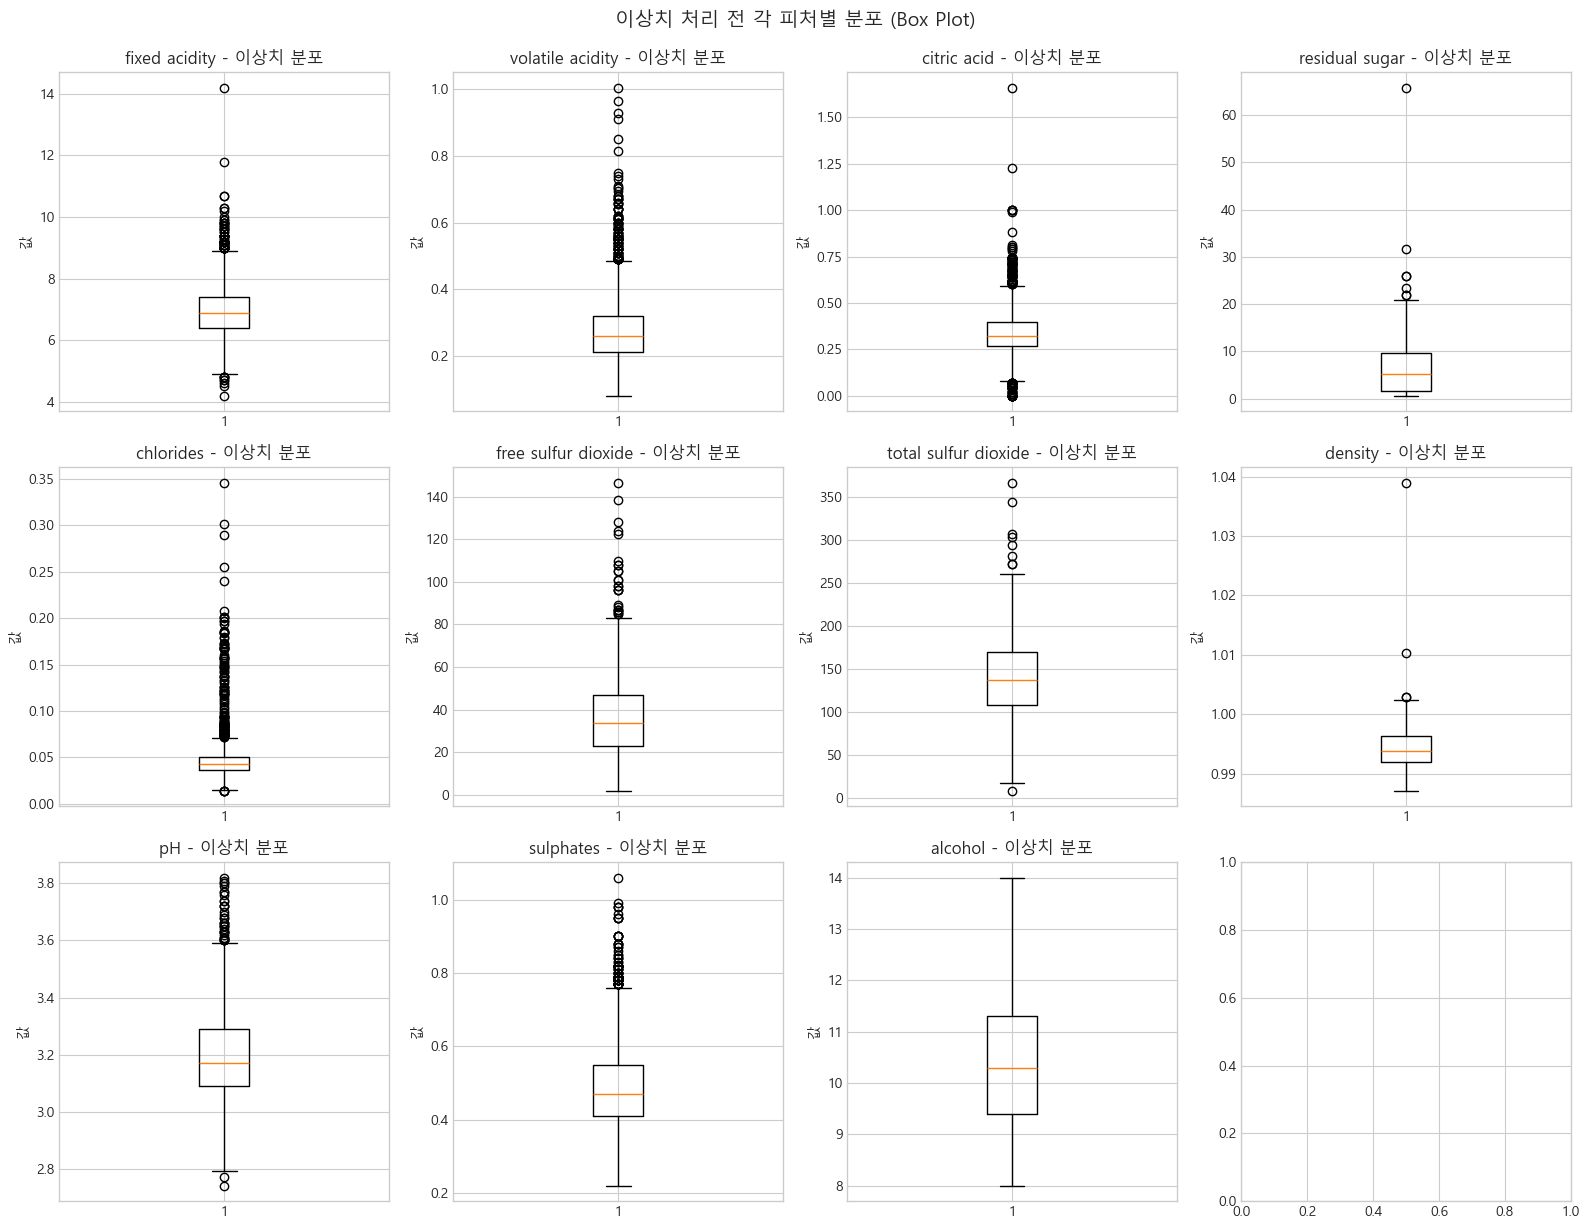

이상치로 판단되는 행 개수: 564 / 3200 (17.62%)


In [6]:
# 이상치 시각화 - Box Plot
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for idx, col in enumerate(X_train_filled.columns):
    axes[idx].boxplot(X_train_filled[col])
    axes[idx].set_title(f'{col} - 이상치 분포')
    axes[idx].set_ylabel('값')
    
plt.tight_layout()
plt.suptitle('이상치 처리 전 각 피처별 분포 (Box Plot)', y=1.02, fontsize=14)
plt.show()

# IQR 기반 이상치 개수 확인
Q1 = X_train_filled.quantile(0.25)
Q3 = X_train_filled.quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((X_train_filled < (Q1 - 1.5 * IQR)) | (X_train_filled > (Q3 + 1.5 * IQR))).any(axis=1)
print(f"이상치로 판단되는 행 개수: {outlier_mask.sum()} / {len(X_train_filled)} ({outlier_mask.sum()/len(X_train_filled)*100:.2f}%)")


In [7]:
def remove_outliers_iqr(df, y):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1
    
    # 이상치 범위: Q1 - 1.5*IQR ~ Q3 + 1.5*IQR
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print("=== 이상치 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===")
    outlier_info = pd.DataFrame({
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })
    print(outlier_info)

    # 모든 컬럼에 대해 이상치가 아닌 데이터만 남김 (행 기준)
    condition = ~((df < lower_bound) | (df > upper_bound)).any(axis=1)
    
    return df[condition], y[condition]

print(f"이상치 제거 전 Train 크기: {X_train_filled.shape}")
X_train_cleaned, y_train_cleaned = remove_outliers_iqr(X_train_filled, y_train)
print(f"이상치 제거 후 Train 크기: {X_train_cleaned.shape}")
n_outliers = X_train_filled.shape[0] - X_train_cleaned.shape[0]
print(f"이상치로 판단된 행 수: {n_outliers}개 ({n_outliers/len(X_train_filled)*100:.2f}%)")
print(f"제거된 행 수: {X_train_filled.shape[0] - X_train_cleaned.shape[0]}개")

# Test Set은 건드리지 않음 (X_test_filled 유지)

이상치 제거 전 Train 크기: (3200, 11)
=== 이상치 범위 (Q1 - 1.5*IQR ~ Q3 + 1.5*IQR) ===
                      Lower Bound  Upper Bound
fixed acidity            4.900000     8.900000
volatile acidity         0.045000     0.485000
citric acid              0.075000     0.595000
residual sugar         -10.300000    21.700000
chlorides                0.015000     0.071000
free sulfur dioxide    -13.000000    83.000000
total sulfur dioxide    17.500000   261.500000
density                  0.985299     1.002869
pH                       2.790000     3.590000
sulphates                0.200000     0.760000
alcohol                  6.550000    14.150000
이상치 제거 후 Train 크기: (2636, 11)
이상치로 판단된 행 수: 564개 (17.62%)
제거된 행 수: 564개


In [8]:
# 이상치 제거 전후 데이터터 분포 비교


### 4.3. 스케일링 방법 비교 분석 (Scaling Comparison)

피처 간 스케일 차이가 크므로 스케일링이 필요합니다. 여기서는 다양한 스케일링 방법을 비교 분석하고, **최종 스케일링은 4.6 정규화 비교 섹션에서 Pipeline 내에서 각 fold마다 적용**됩니다.

**비교할 스케일러:**
- `StandardScaler`: 평균 0, 분산 1. 이상치에 민감.
- `MinMaxScaler`: 0~1 사이 값. 이상치에 민감.
- `RobustScaler`: 중앙값과 IQR 사용. 이상치에 강함.

**참고:** 데이터 누수(Data Leakage)를 방지하기 위해 스케일링은 교차검증의 각 fold 내에서 개별적으로 적용되어야 합니다.


**스케일링 방법별 시각적 비교**

아래 코드는 각 스케일링 방법이 데이터 분포에 미치는 영향을 시각적으로 비교합니다.


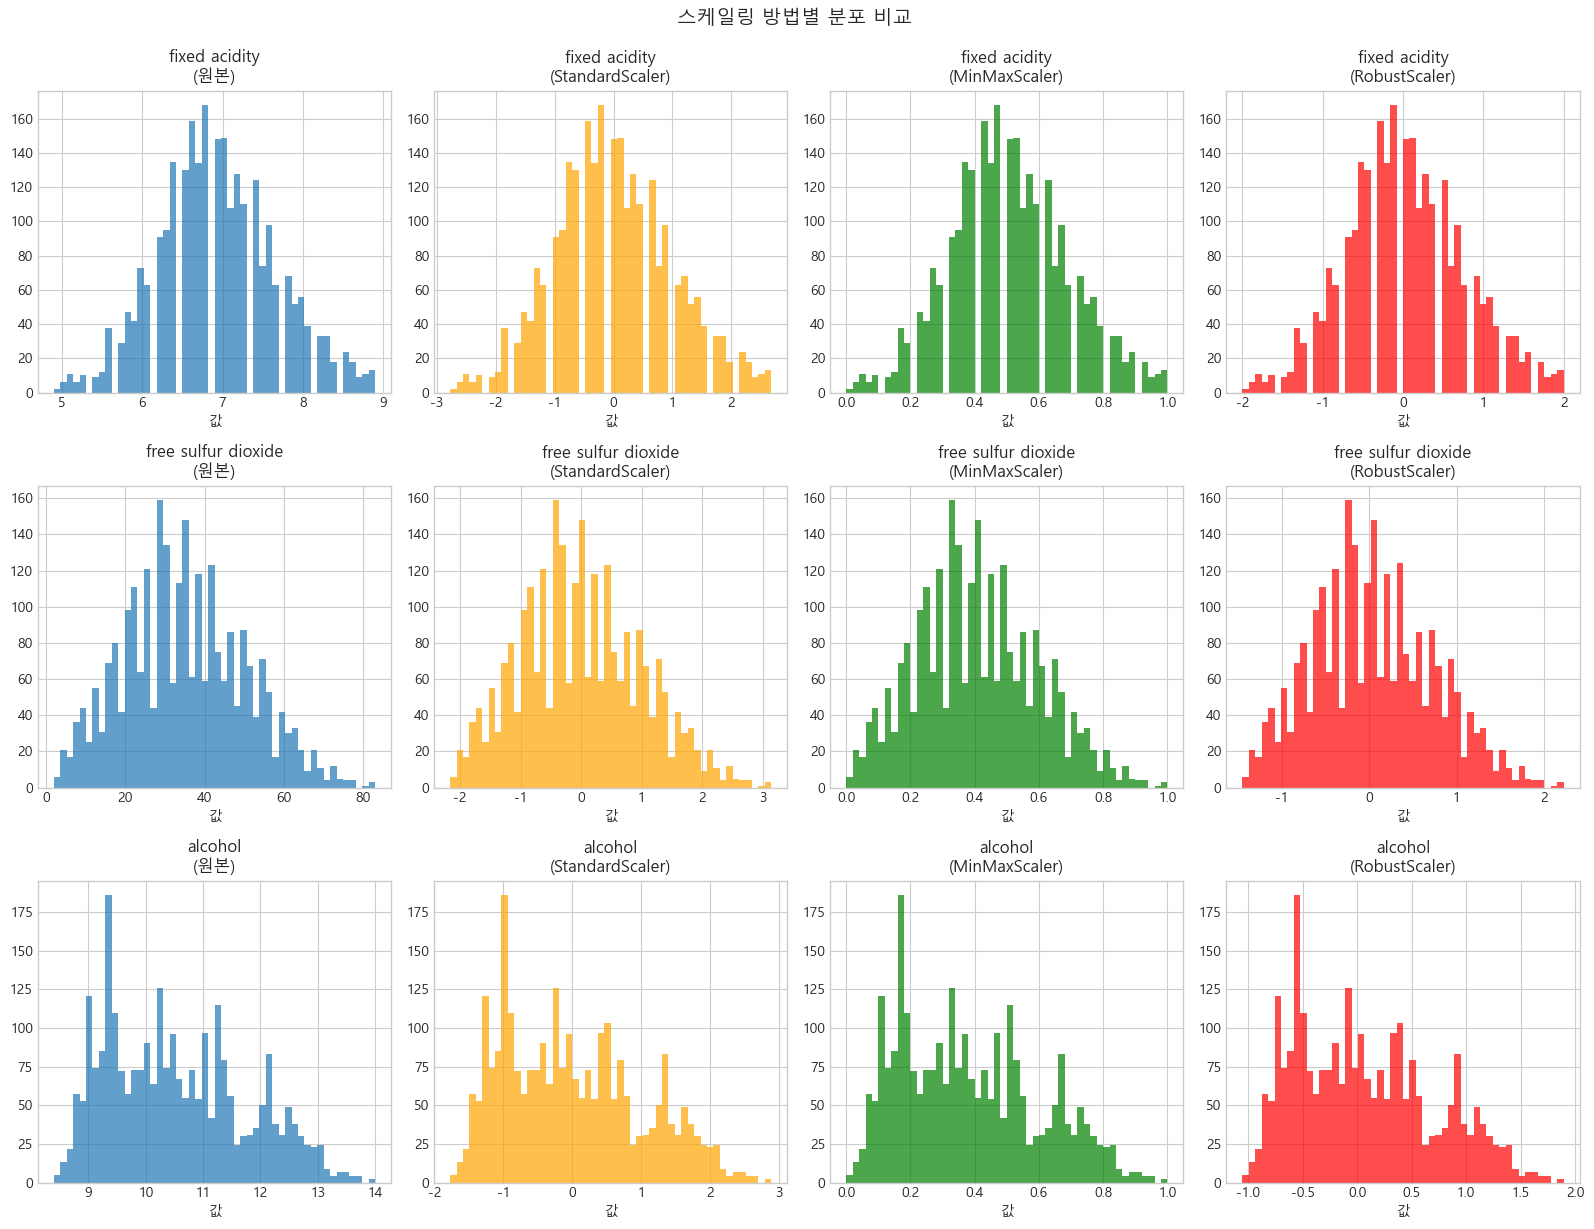

스케일링 방법별 통계량 비교 (대표 피처: fixed acidity):
                원본  StandardScaler  MinMaxScaler  RobustScaler
count  2636.000000    2.636000e+03   2636.000000   2636.000000
mean      6.936760    7.844004e-16      0.509190      0.036760
std       0.732708    1.000190e+00      0.183177      0.732708
min       4.900000   -2.780299e+00      0.000000     -2.000000
25%       6.400000   -7.327097e-01      0.375000     -0.500000
50%       6.900000   -5.017992e-02      0.500000      0.000000
75%       7.400000    6.323498e-01      0.625000      0.500000
max       8.900000    2.679939e+00      1.000000      2.000000


In [9]:
# 다양한 스케일러 적용 및 비교
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()
scaler_robust = RobustScaler()

X_train_std = scaler_std.fit_transform(X_train_cleaned)
X_train_minmax = scaler_minmax.fit_transform(X_train_cleaned)
X_train_robust = scaler_robust.fit_transform(X_train_cleaned)

# 시각화: 스케일링 전후 비교 (대표 피처 3개)
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
feature_indices = [0, 5, 10]  # fixed acidity, total sulfur dioxide, alcohol
feature_names = [X_train_cleaned.columns[i] for i in feature_indices]

for row, feat_idx in enumerate(feature_indices):
    feat_name = feature_names[row]
    
    # 원본
    axes[row, 0].hist(X_train_cleaned.iloc[:, feat_idx], bins=50, alpha=0.7)
    axes[row, 0].set_title(f'{feat_name}\n(원본)')
    axes[row, 0].set_xlabel('값')
    
    # StandardScaler
    axes[row, 1].hist(X_train_std[:, feat_idx], bins=50, alpha=0.7, color='orange')
    axes[row, 1].set_title(f'{feat_name}\n(StandardScaler)')
    axes[row, 1].set_xlabel('값')
    
    # MinMaxScaler
    axes[row, 2].hist(X_train_minmax[:, feat_idx], bins=50, alpha=0.7, color='green')
    axes[row, 2].set_title(f'{feat_name}\n(MinMaxScaler)')
    axes[row, 2].set_xlabel('값')
    
    # RobustScaler
    axes[row, 3].hist(X_train_robust[:, feat_idx], bins=50, alpha=0.7, color='red')
    axes[row, 3].set_title(f'{feat_name}\n(RobustScaler)')
    axes[row, 3].set_xlabel('값')

plt.tight_layout()
plt.suptitle('스케일링 방법별 분포 비교', y=1.02, fontsize=14)
plt.show()

# 통계량 비교
comparison_df = pd.DataFrame({
    '원본': X_train_cleaned.iloc[:, 0].describe(),
    'StandardScaler': pd.Series(X_train_std[:, 0]).describe(),
    'MinMaxScaler': pd.Series(X_train_minmax[:, 0]).describe(),
    'RobustScaler': pd.Series(X_train_robust[:, 0]).describe()
})
print("스케일링 방법별 통계량 비교 (대표 피처: fixed acidity):")
print(comparison_df)


**스케일링 비교 분석 결론:**
- 세 가지 스케일러 모두 데이터 분포의 형태를 유지하면서 스케일을 조정합니다.
- StandardScaler: 평균 0, 표준편차 1로 변환하여 선형 모델에 적합합니다.
- MinMaxScaler: 0~1 범위로 변환하여 신경망에 적합합니다.
- RobustScaler: 중앙값과 IQR 기반으로 이상치에 덜 민감합니다.

**최종 스케일링 선택은 4.6 정규화 비교 섹션에서 교차검증을 통해 결정합니다.**


In [10]:
# 스케일링은 4.6 정규화 비교 섹션에서 Pipeline 내에서 적용됩니다.
# 데이터 누수 방지를 위해 스케일링을 교차검증의 각 fold 내에서 개별 적용합니다.
# 아래 코드는 참고용으로 주석 처리합니다.

# scaler = StandardScaler()
# scaler.fit(X_train_cleaned)
# X_train_scaled = pd.DataFrame(scaler.transform(X_train_cleaned), columns=X_train_cleaned.columns, index=X_train_cleaned.index)
# X_test_scaled = pd.DataFrame(scaler.transform(X_test_filled), columns=X_test_filled.columns, index=X_test_filled.index)

# 피처 선택을 위해 이상치 제거된 데이터를 직접 사용합니다
X_train_for_selection = X_train_cleaned.copy()
y_train_for_selection = y_train_cleaned.copy()

print(f"피처 선택을 위한 Train 데이터 크기: {X_train_for_selection.shape}")
print(f"Test 데이터 크기: {X_test_filled.shape}")

피처 선택을 위한 Train 데이터 크기: (2636, 11)
Test 데이터 크기: (801, 11)


### 4.4. 불균형 데이터 처리 전략 (Imbalanced Data Handling Strategy)

Quality 3, 9와 같은 소수 클래스의 예측 성능을 높여야 합니다.

**현재 클래스 분포 분석:**
- 소수 클래스(Quality 3, 9)의 샘플이 매우 적습니다.
- 이러한 불균형은 모델이 다수 클래스에 편향되는 문제를 야기합니다.

**샘플링 방법 비교:**
| 방법 | 장점 | 단점 |
|------|------|------|
| RandomOverSampler | 단순, 빠름 | 과적합 위험 |
| SMOTE | 새로운 샘플 생성 | 클래스 경계 모호화 가능 |
| SMOTETomek | SMOTE + 노이즈 제거 | 계산 비용 높음 |

**결정: SMOTETomek + Pipeline + StratifiedKFold**

데이터 누수(Data Leakage)를 방지하기 위해 **Pipeline 내에서 각 CV fold마다 SMOTETomek을 개별 적용**합니다.
- 스케일링과 SMOTE를 Pipeline에 통합하여 각 fold에서 독립적으로 적용
- StratifiedKFold로 클래스 비율을 유지하면서 교차검증 수행

현재 클래스 분포 (이상치 제거 후)
quality
3       7
4      62
5     745
6    1168
7     547
8     104
9       3
Name: count, dtype: int64


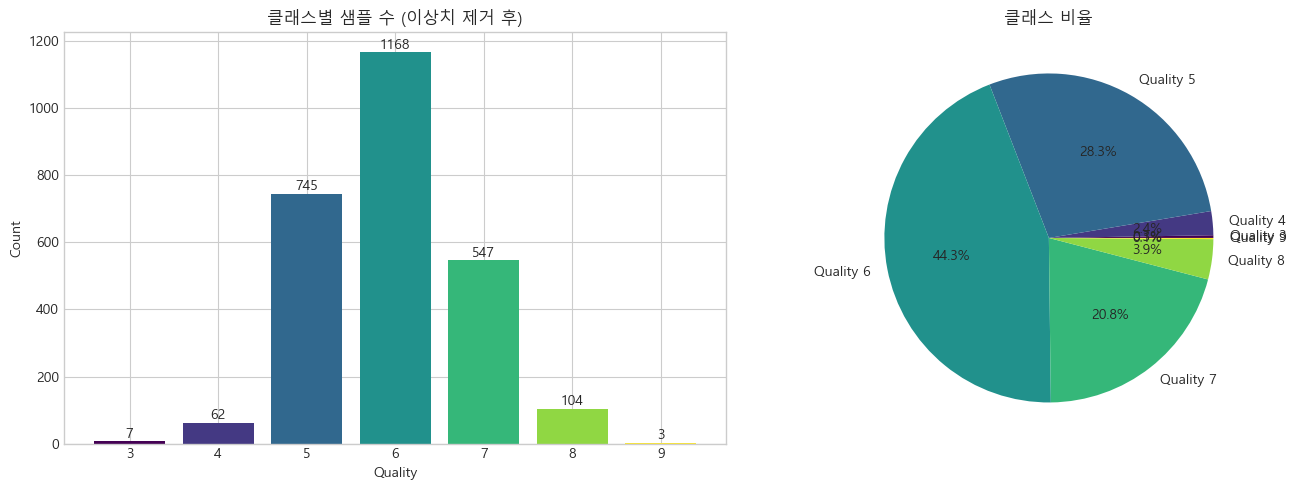


불균형 비율 (다수/소수): 389.33
가장 적은 클래스: Quality 9 (3개)
가장 많은 클래스: Quality 6 (1168개)


In [11]:
# 추가 라이브러리 임포트
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif, SelectFromModel

# 현재 클래스 분포 시각화
print("=" * 50)
print("현재 클래스 분포 (이상치 제거 후)")
print("=" * 50)

class_dist = pd.Series(y_train_for_selection).value_counts().sort_index()
print(class_dist)

# 클래스 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 막대 그래프
colors = plt.cm.viridis(np.linspace(0, 1, len(class_dist)))
axes[0].bar(class_dist.index.astype(str), class_dist.values, color=colors)
axes[0].set_xlabel('Quality')
axes[0].set_ylabel('Count')
axes[0].set_title('클래스별 샘플 수 (이상치 제거 후)')
for i, (idx, val) in enumerate(zip(class_dist.index, class_dist.values)):
    axes[0].text(i, val + 10, str(val), ha='center', fontsize=10)

# 파이 차트
axes[1].pie(class_dist.values, labels=[f'Quality {i}' for i in class_dist.index], 
            autopct='%1.1f%%', colors=colors)
axes[1].set_title('클래스 비율')

plt.tight_layout()
plt.show()

# 불균형 비율 계산
majority_class = class_dist.max()
minority_class = class_dist.min()
imbalance_ratio = majority_class / minority_class
print(f"\n불균형 비율 (다수/소수): {imbalance_ratio:.2f}")
print(f"가장 적은 클래스: Quality {class_dist.idxmin()} ({minority_class}개)")
print(f"가장 많은 클래스: Quality {class_dist.idxmax()} ({majority_class}개)")

**Pipeline + StratifiedKFold 구조 정의**

데이터 누수를 방지하기 위해 다음과 같은 Pipeline 구조를 사용합니다:
1. `Scaler`: 각 fold에서 독립적으로 스케일링 학습/적용
2. `SMOTETomek`: 각 fold의 학습 데이터에만 오버샘플링 적용
3. `Classifier`: 모델 학습

이 구조는 4.6 정규화 비교 섹션에서 다양한 스케일러와 함께 평가됩니다.


In [12]:
# Pipeline + StratifiedKFold 구조 정의
# SMOTE k_neighbors를 최소 클래스 샘플 수보다 작게 설정 (k_neighbors=2)
smote_config = SMOTE(k_neighbors=2, random_state=42)
smote_tomek = SMOTETomek(smote=smote_config, random_state=42)

# StratifiedKFold 설정 (클래스 비율 유지)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline 정의 함수
def create_pipeline(scaler, classifier):
    """스케일러와 분류기를 포함한 Pipeline 생성"""
    return ImbPipeline([
        ('scaler', scaler),
        ('smote', SMOTETomek(smote=SMOTE(k_neighbors=2, random_state=42), random_state=42)),
        ('clf', classifier)
    ])

# 기본 Pipeline 예시 (StandardScaler + RandomForest)
base_pipeline = create_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))

print("Pipeline 구조:")
print(base_pipeline)
print("\n각 fold에서 스케일링과 SMOTE가 독립적으로 적용됩니다.")


Pipeline 구조:
Pipeline(steps=[('scaler', StandardScaler()),
                ('smote',
                 SMOTETomek(random_state=42,
                            smote=SMOTE(k_neighbors=2, random_state=42))),
                ('clf', RandomForestClassifier(random_state=42))])

각 fold에서 스케일링과 SMOTE가 독립적으로 적용됩니다.


**4.4 불균형 데이터 처리 분석 결론:**

1. **심각한 클래스 불균형**: Quality 3, 9는 각각 매우 적은 샘플을 가지고 있어 SMOTE 적용 시 k_neighbors를 2로 설정
2. **SMOTETomek 먼저 적용**: 전체 Train 데이터에 SMOTETomek을 먼저 적용하여 클래스 불균형 해소
3. **StratifiedKFold 적용**: 샘플링된 데이터에 대해 StratifiedKFold로 교차검증 수행
4. **주의사항**: SMOTE를 전체 데이터에 먼저 적용하므로 약간의 데이터 누수 가능성이 있으나, 각 fold에서 소수 클래스가 없어지는 문제를 방지

이제 피처 선택을 진행하여 모델에 사용할 최적의 피처를 결정합니다.


### 4.5. 피처 선택 종합 분석 (Feature Selection Comprehensive Analysis)

과제의 "적은 개수의 필드로 예측" 요구사항을 충족하고 다중공선성 문제를 해결해야 합니다.

**5가지 피처 선택 방법 비교:**

| 방법 | 설명 | 장점 | 단점 |
|------|------|------|------|
| **VIF** | 다중공선성 분석 | 변수 간 상관관계 파악 | 타겟과의 관계 미고려 |
| **상관관계** | 타겟과의 상관계수 | 직관적 해석 | 비선형 관계 미반영 |
| **Univariate** | 개별 피처 통계 검정 | 빠른 계산 | 피처 간 상호작용 미고려 |
| **Model-Based** | 모델 기반 중요도 | 비선형 관계 포착 | 모델 의존적 |
| **RFE** | 재귀적 제거 | 피처 상호작용 고려 | 계산 비용 높음 |

**목표:** 5가지 방법의 결과를 종합하여 최적의 피처 세트 선택

4.5.1 VIF (Variance Inflation Factor) 분석

VIF 분석 결과 (VIF > 10: 다중공선성 의심):
                Features        VIF
7                density  44.426408
3         residual sugar  17.711193
10               alcohol  12.006983
0          fixed acidity   2.944646
6   total sulfur dioxide   2.505068
8                     pH   2.380971
5    free sulfur dioxide   1.883875
4              chlorides   1.604882
9              sulphates   1.161774
1       volatile acidity   1.141559
2            citric acid   1.100409

VIF < 10인 피처 (8개): ['fixed acidity', 'total sulfur dioxide', 'pH', 'free sulfur dioxide', 'chlorides', 'sulphates', 'volatile acidity', 'citric acid']


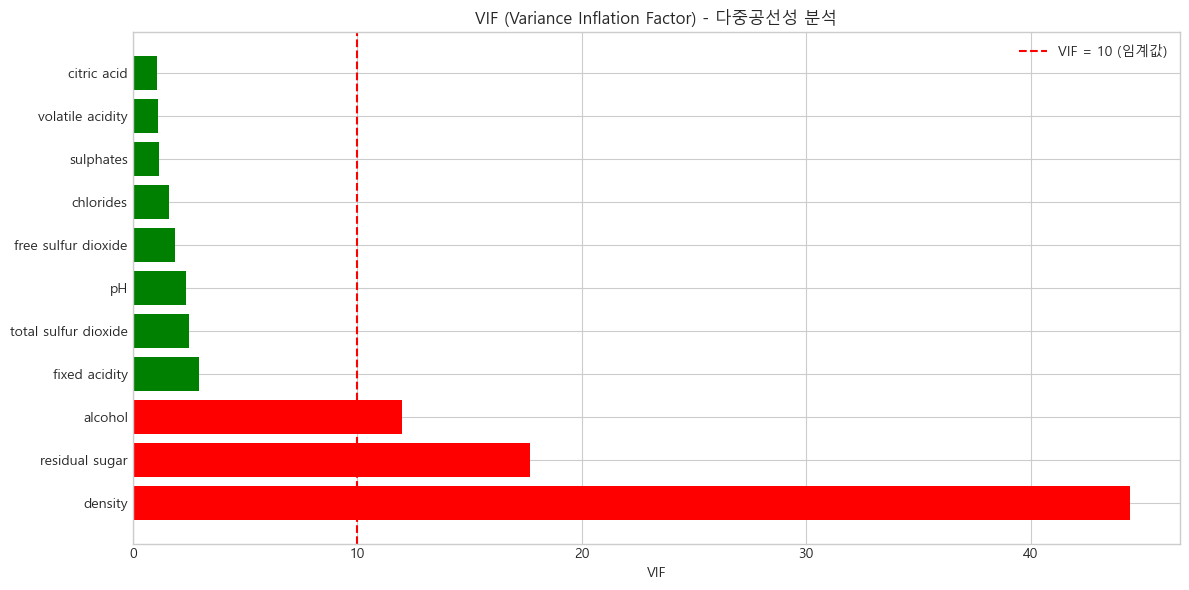

In [13]:
# ============================================
# 4.5.1 VIF (Variance Inflation Factor) 분석
# ============================================
print("=" * 60)
print("4.5.1 VIF (Variance Inflation Factor) 분석")
print("=" * 60)

def calculate_vif(df):
    """VIF 계산 함수 - 다중공선성 분석"""
    vif = pd.DataFrame()
    vif["Features"] = df.columns
    vif["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif.sort_values(by="VIF", ascending=False)

# 스케일링 후 VIF 계산 (스케일링이 VIF에 영향을 줄 수 있음)
scaler_temp = StandardScaler()
X_scaled_temp = pd.DataFrame(
    scaler_temp.fit_transform(X_train_for_selection),
    columns=X_train_for_selection.columns
)

vif_results = calculate_vif(X_scaled_temp)
print("\nVIF 분석 결과 (VIF > 10: 다중공선성 의심):")
print(vif_results)

# VIF 기준 피처 선택 (VIF < 10인 피처)
vif_selected = vif_results[vif_results['VIF'] < 10]['Features'].tolist()
print(f"\nVIF < 10인 피처 ({len(vif_selected)}개): {vif_selected}")

# VIF 시각화
plt.figure(figsize=(12, 6))
colors = ['red' if v > 10 else 'green' for v in vif_results['VIF']]
plt.barh(vif_results['Features'], vif_results['VIF'], color=colors)
plt.axvline(x=10, color='red', linestyle='--', label='VIF = 10 (임계값)')
plt.xlabel('VIF')
plt.title('VIF (Variance Inflation Factor) - 다중공선성 분석')
plt.legend()
plt.tight_layout()
plt.show()

4.5.2 상관관계 분석 (Correlation Analysis)

피처-타겟 상관관계 (절대값):
alcohol                 0.439080
density                 0.324982
chlorides               0.287630
total sulfur dioxide    0.158692
residual sugar          0.134187
volatile acidity        0.110840
pH                      0.099446
fixed acidity           0.071151
free sulfur dioxide     0.030537
sulphates               0.028930
citric acid             0.013784
dtype: float64

상관관계 상위 6개 피처: ['alcohol', 'density', 'chlorides', 'total sulfur dioxide', 'residual sugar', 'volatile acidity']


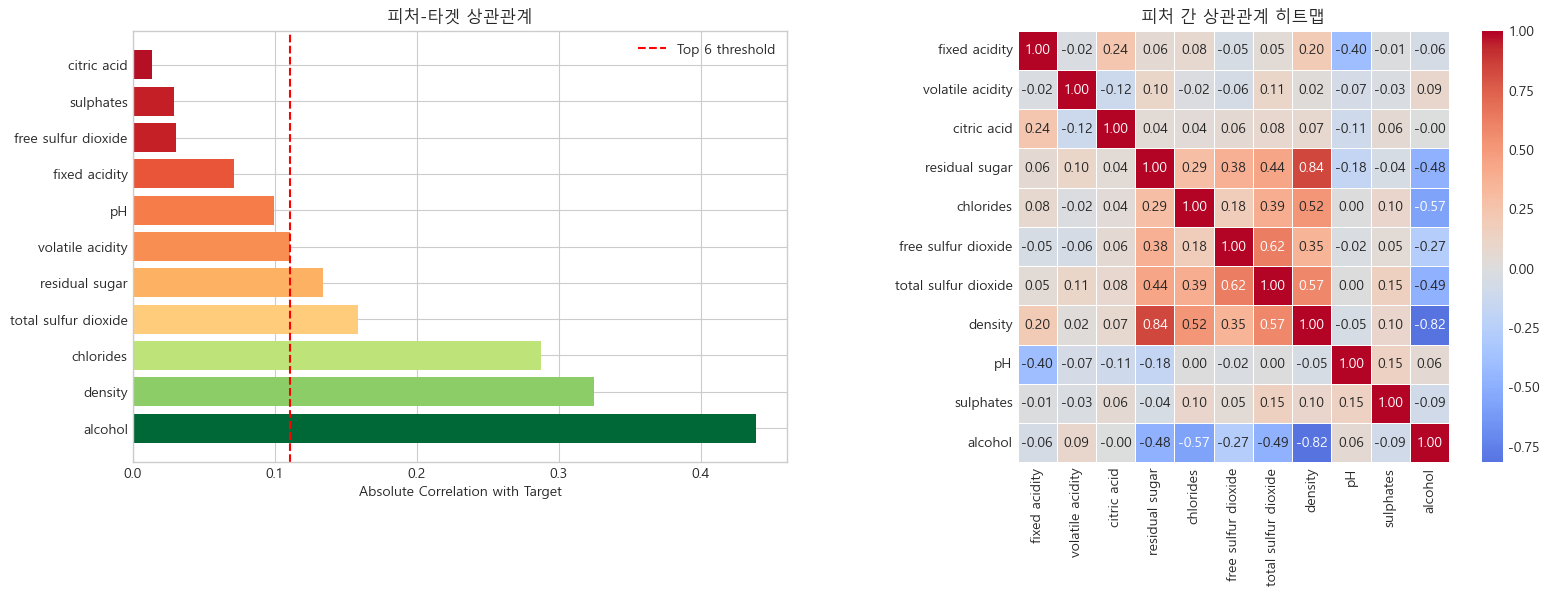

In [14]:
# ============================================
# 4.5.2 상관관계 분석 (Correlation Analysis)
# ============================================
print("=" * 60)
print("4.5.2 상관관계 분석 (Correlation Analysis)")
print("=" * 60)

# 피처-타겟 상관관계 계산
feature_target_corr = X_train_for_selection.apply(lambda x: x.corr(y_train_for_selection))
feature_target_corr = feature_target_corr.abs().sort_values(ascending=False)

print("\n피처-타겟 상관관계 (절대값):")
print(feature_target_corr)

# 상관관계 기준 상위 6개 피처 선택
n_select = 6
corr_selected = feature_target_corr.head(n_select).index.tolist()
print(f"\n상관관계 상위 {n_select}개 피처: {corr_selected}")

# 상관관계 히트맵
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 피처-타겟 상관관계
ax1 = axes[0]
colors = plt.cm.RdYlGn(feature_target_corr.values / feature_target_corr.max())
bars = ax1.barh(feature_target_corr.index, feature_target_corr.values, color=colors)
ax1.set_xlabel('Absolute Correlation with Target')
ax1.set_title('피처-타겟 상관관계')
ax1.axvline(x=feature_target_corr.iloc[n_select-1], color='red', linestyle='--', label=f'Top {n_select} threshold')
ax1.legend()

# 피처 간 상관관계 히트맵
ax2 = axes[1]
corr_matrix = X_train_for_selection.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax2, 
            center=0, square=True, linewidths=0.5)
ax2.set_title('피처 간 상관관계 히트맵')

plt.tight_layout()
plt.show()

4.5.3 Univariate 분석 (SelectKBest)

f_classif (ANOVA F-value) 점수:
                Features     F_Score
10               alcohol  126.188478
7                density   63.188434
4              chlorides   44.397112
6   total sulfur dioxide   24.177743
1       volatile acidity   16.863041
5    free sulfur dioxide   14.475176
3         residual sugar   13.600819
8                     pH    5.823645
0          fixed acidity    4.159475
9              sulphates    1.181751
2            citric acid    0.866017

f_classif 상위 6개 피처: ['alcohol', 'density', 'chlorides', 'total sulfur dioxide', 'volatile acidity', 'free sulfur dioxide']

mutual_info_classif (상호정보량) 점수:
                Features  MI_Score
7                density  0.174155
10               alcohol  0.150615
3         residual sugar  0.107623
5    free sulfur dioxide  0.081178
6   total sulfur dioxide  0.073793
4              chlorides  0.065770
2            citric acid  0.039705
9              sulphates  0.034597
0          fixed ac

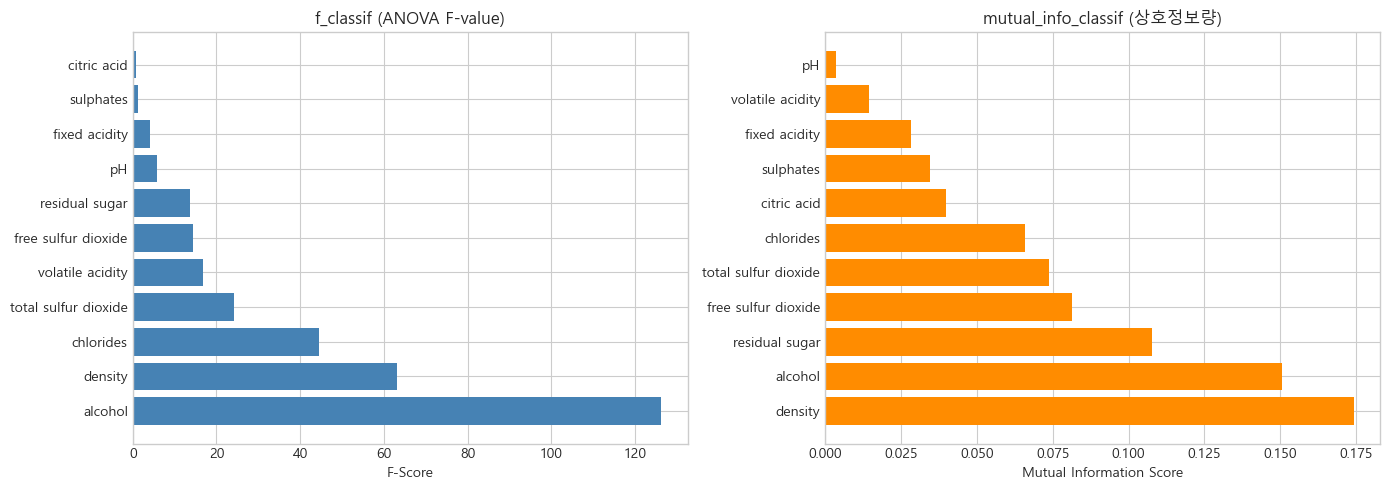

In [15]:
# ============================================
# 4.5.3 Univariate 분석 (SelectKBest)
# ============================================
print("=" * 60)
print("4.5.3 Univariate 분석 (SelectKBest)")
print("=" * 60)

# f_classif (ANOVA F-value)
selector_f = SelectKBest(score_func=f_classif, k=n_select)
selector_f.fit(X_scaled_temp, y_train_for_selection)
f_scores = pd.DataFrame({
    'Features': X_train_for_selection.columns,
    'F_Score': selector_f.scores_
}).sort_values(by='F_Score', ascending=False)

print("\nf_classif (ANOVA F-value) 점수:")
print(f_scores)

univariate_f_selected = f_scores.head(n_select)['Features'].tolist()
print(f"\nf_classif 상위 {n_select}개 피처: {univariate_f_selected}")

# mutual_info_classif
selector_mi = SelectKBest(score_func=mutual_info_classif, k=n_select)
selector_mi.fit(X_scaled_temp, y_train_for_selection)
mi_scores = pd.DataFrame({
    'Features': X_train_for_selection.columns,
    'MI_Score': selector_mi.scores_
}).sort_values(by='MI_Score', ascending=False)

print("\nmutual_info_classif (상호정보량) 점수:")
print(mi_scores)

univariate_mi_selected = mi_scores.head(n_select)['Features'].tolist()
print(f"\nmutual_info 상위 {n_select}개 피처: {univariate_mi_selected}")

# Univariate 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(f_scores['Features'], f_scores['F_Score'], color='steelblue')
axes[0].set_xlabel('F-Score')
axes[0].set_title('f_classif (ANOVA F-value)')

axes[1].barh(mi_scores['Features'], mi_scores['MI_Score'], color='darkorange')
axes[1].set_xlabel('Mutual Information Score')
axes[1].set_title('mutual_info_classif (상호정보량)')

plt.tight_layout()
plt.show()

4.5.4 Model-Based 분석 (RandomForest Feature Importance)

RandomForest Feature Importance:
                Features  Importance
10               alcohol    0.112556
7                density    0.107589
5    free sulfur dioxide    0.095343
6   total sulfur dioxide    0.092419
3         residual sugar    0.091829
1       volatile acidity    0.090048
8                     pH    0.089273
9              sulphates    0.083275
4              chlorides    0.082457
2            citric acid    0.080911
0          fixed acidity    0.074299

Model-Based 상위 6개 피처: ['alcohol', 'density', 'free sulfur dioxide', 'total sulfur dioxide', 'residual sugar', 'volatile acidity']
SelectFromModel (median threshold) 선택 피처: ['volatile acidity', 'residual sugar', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'alcohol']


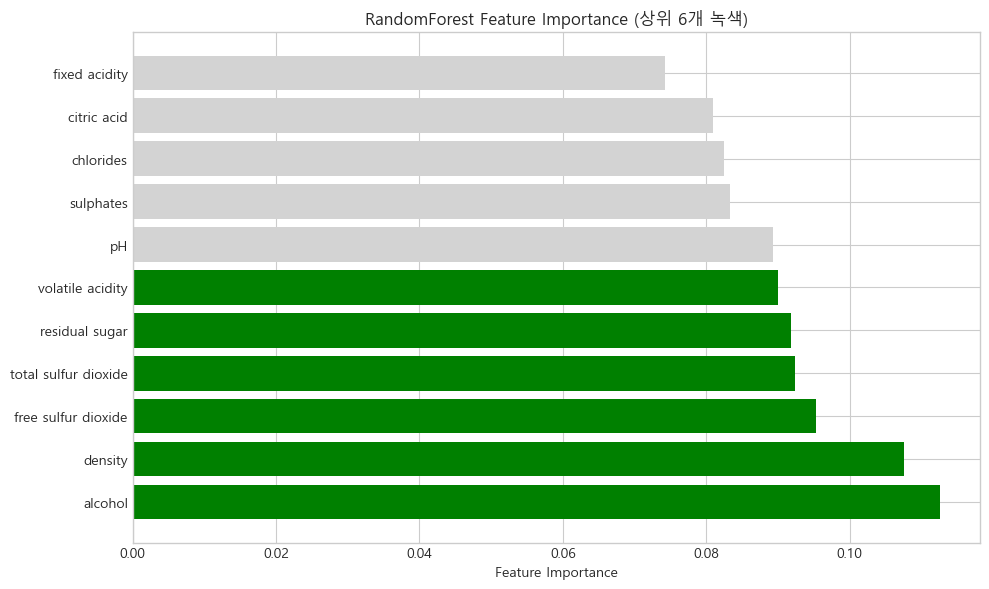

In [16]:
# ============================================
# 4.5.4 Model-Based 분석 (SelectFromModel)
# ============================================
print("=" * 60)
print("4.5.4 Model-Based 분석 (RandomForest Feature Importance)")
print("=" * 60)

# RandomForest로 피처 중요도 계산
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_scaled_temp, y_train_for_selection)

# 피처 중요도 추출
rf_importance = pd.DataFrame({
    'Features': X_train_for_selection.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nRandomForest Feature Importance:")
print(rf_importance)

# Model-Based 상위 피처 선택
model_based_selected = rf_importance.head(n_select)['Features'].tolist()
print(f"\nModel-Based 상위 {n_select}개 피처: {model_based_selected}")

# SelectFromModel로 자동 선택
sfm = SelectFromModel(rf_selector, threshold='median')
sfm.fit(X_scaled_temp, y_train_for_selection)
sfm_selected = X_train_for_selection.columns[sfm.get_support()].tolist()
print(f"SelectFromModel (median threshold) 선택 피처: {sfm_selected}")

# 시각화
plt.figure(figsize=(10, 6))
colors = ['green' if f in model_based_selected else 'lightgray' for f in rf_importance['Features']]
plt.barh(rf_importance['Features'], rf_importance['Importance'], color=colors)
plt.xlabel('Feature Importance')
plt.title('RandomForest Feature Importance (상위 6개 녹색)')
plt.tight_layout()
plt.show()


4.5.5 RFE (Recursive Feature Elimination) 분석

RFE 결과:
                Features  Selected  Ranking
3         residual sugar      True        1
7                density      True        1
6   total sulfur dioxide      True        1
5    free sulfur dioxide      True        1
10               alcohol      True        1
8                     pH      True        1
1       volatile acidity     False        2
4              chlorides     False        3
9              sulphates     False        4
2            citric acid     False        5
0          fixed acidity     False        6

RFE 선택 피처 (6개): ['residual sugar', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'alcohol']


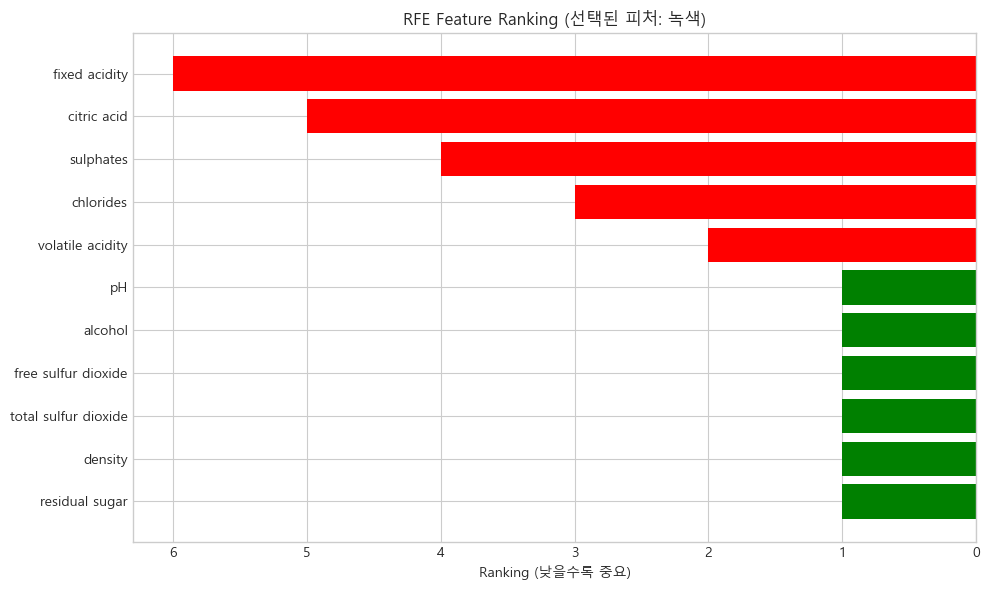

In [17]:
# ============================================
# 4.5.5 RFE (Recursive Feature Elimination) 분석
# ============================================
print("=" * 60)
print("4.5.5 RFE (Recursive Feature Elimination) 분석")
print("=" * 60)

# RFE로 피처 선택
rfe_estimator = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=n_select)
rfe.fit(X_scaled_temp, y_train_for_selection)

# RFE 결과
rfe_results = pd.DataFrame({
    'Features': X_train_for_selection.columns,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values(by='Ranking')

print("\nRFE 결과:")
print(rfe_results)

rfe_selected = X_train_for_selection.columns[rfe.support_].tolist()
print(f"\nRFE 선택 피처 ({n_select}개): {rfe_selected}")

# RFE 시각화
plt.figure(figsize=(10, 6))
colors = ['green' if s else 'red' for s in rfe_results['Selected']]
plt.barh(rfe_results['Features'], rfe_results['Ranking'], color=colors)
plt.xlabel('Ranking (낮을수록 중요)')
plt.title('RFE Feature Ranking (선택된 피처: 녹색)')
plt.gca().invert_xaxis()  # 낮은 랭킹이 좋으므로 축 반전
plt.tight_layout()
plt.show()


In [18]:
# ============================================
# 4.5.6 종합 분석 및 최종 피처 선택
# ============================================
print("=" * 60)
print("4.5.6 종합 분석 및 최종 피처 선택")
print("=" * 60)

# 각 방법별 선택된 피처 수집
all_methods = {
    'Correlation': corr_selected,
    'F_classif': univariate_f_selected,
    'Mutual_Info': univariate_mi_selected,
    'Model_Based': model_based_selected,
    'RFE': rfe_selected
}

# 피처별 선택 횟수 계산
feature_counts = {}
for feature in X_train_for_selection.columns:
    count = sum(1 for method_features in all_methods.values() if feature in method_features)
    feature_counts[feature] = count

feature_selection_summary = pd.DataFrame({
    'Feature': feature_counts.keys(),
    'Selection_Count': feature_counts.values()
}).sort_values(by='Selection_Count', ascending=False)

print("\n피처별 선택 횟수 (5가지 방법 중):")
print(feature_selection_summary)

# 종합 점수 테이블 생성
summary_table = pd.DataFrame(index=X_train_for_selection.columns)
summary_table['VIF'] = vif_results.set_index('Features')['VIF']
summary_table['Correlation'] = feature_target_corr
summary_table['F_Score'] = f_scores.set_index('Features')['F_Score']
summary_table['MI_Score'] = mi_scores.set_index('Features')['MI_Score']
summary_table['RF_Importance'] = rf_importance.set_index('Features')['Importance']
summary_table['RFE_Rank'] = rfe_results.set_index('Features')['Ranking']
summary_table['Selection_Count'] = feature_selection_summary.set_index('Feature')['Selection_Count']

# 정규화된 종합 점수 계산
from sklearn.preprocessing import MinMaxScaler
scaler_norm = MinMaxScaler()

# VIF는 낮을수록 좋으므로 반전
summary_table['VIF_Normalized'] = 1 - scaler_norm.fit_transform(summary_table[['VIF']])
summary_table['Corr_Normalized'] = scaler_norm.fit_transform(summary_table[['Correlation']])
summary_table['F_Normalized'] = scaler_norm.fit_transform(summary_table[['F_Score']])
summary_table['MI_Normalized'] = scaler_norm.fit_transform(summary_table[['MI_Score']])
summary_table['RF_Normalized'] = scaler_norm.fit_transform(summary_table[['RF_Importance']])
# RFE_Rank는 낮을수록 좋으므로 반전
summary_table['RFE_Normalized'] = 1 - scaler_norm.fit_transform(summary_table[['RFE_Rank']])

# 종합 점수 (가중 평균)
summary_table['Total_Score'] = (
    summary_table['VIF_Normalized'] * 0.1 +
    summary_table['Corr_Normalized'] * 0.15 +
    summary_table['F_Normalized'] * 0.15 +
    summary_table['MI_Normalized'] * 0.15 +
    summary_table['RF_Normalized'] * 0.2 +
    summary_table['RFE_Normalized'] * 0.25
)

summary_table = summary_table.sort_values(by='Total_Score', ascending=False)

print("\n종합 점수 테이블:")
print(summary_table[['VIF', 'Correlation', 'F_Score', 'MI_Score', 'RF_Importance', 'RFE_Rank', 'Selection_Count', 'Total_Score']].round(4))

# 최종 피처 선택 (종합 점수 기준 상위 6개)
final_selected_features = summary_table.head(n_select).index.tolist()
print(f"\n최종 선택된 피처 ({n_select}개): {final_selected_features}")


4.5.6 종합 분석 및 최종 피처 선택

피처별 선택 횟수 (5가지 방법 중):
                 Feature  Selection_Count
10               alcohol                5
7                density                5
6   total sulfur dioxide                5
5    free sulfur dioxide                4
3         residual sugar                4
1       volatile acidity                3
4              chlorides                3
8                     pH                1
0          fixed acidity                0
2            citric acid                0
9              sulphates                0

종합 점수 테이블:
                          VIF  Correlation   F_Score  MI_Score  RF_Importance  \
alcohol               12.0070       0.4391  126.1885    0.1506         0.1126   
density               44.4264       0.3250   63.1884    0.1742         0.1076   
total sulfur dioxide   2.5051       0.1587   24.1777    0.0738         0.0924   
residual sugar        17.7112       0.1342   13.6008    0.1076         0.0918   
free sulfur dioxide    1.8839    

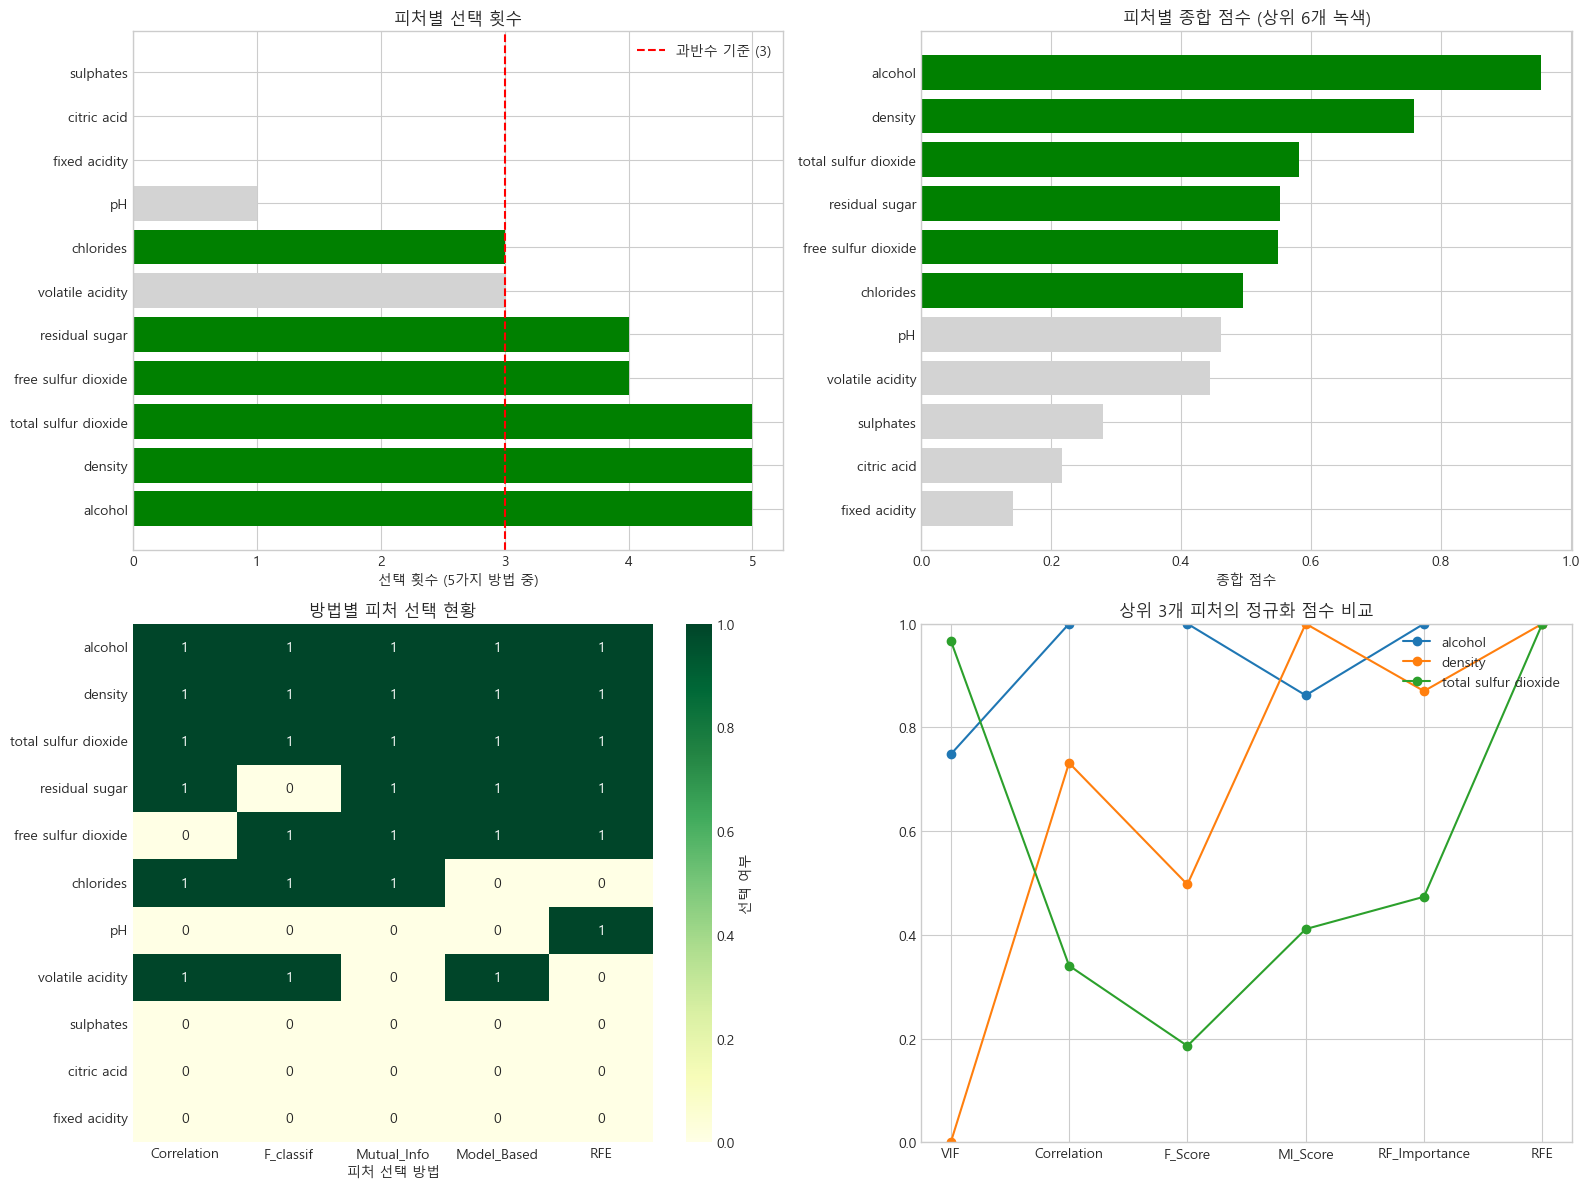


최종 Train 데이터 shape: (2636, 6)
최종 Test 데이터 shape: (801, 6)


In [19]:
# 종합 분석 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 피처별 선택 횟수 막대 그래프
ax1 = axes[0, 0]
colors = ['green' if f in final_selected_features else 'lightgray' 
          for f in feature_selection_summary['Feature']]
ax1.barh(feature_selection_summary['Feature'], feature_selection_summary['Selection_Count'], 
         color=colors)
ax1.set_xlabel('선택 횟수 (5가지 방법 중)')
ax1.set_title('피처별 선택 횟수')
ax1.axvline(x=3, color='red', linestyle='--', label='과반수 기준 (3)')
ax1.legend()

# 2. 종합 점수 막대 그래프
ax2 = axes[0, 1]
sorted_summary = summary_table.sort_values(by='Total_Score', ascending=True)
colors = ['green' if f in final_selected_features else 'lightgray' 
          for f in sorted_summary.index]
ax2.barh(sorted_summary.index, sorted_summary['Total_Score'], color=colors)
ax2.set_xlabel('종합 점수')
ax2.set_title('피처별 종합 점수 (상위 6개 녹색)')

# 3. 각 방법별 피처 선택 히트맵
ax3 = axes[1, 0]
method_matrix = pd.DataFrame(index=X_train_for_selection.columns)
for method, features in all_methods.items():
    method_matrix[method] = [1 if f in features else 0 for f in method_matrix.index]
method_matrix = method_matrix.loc[summary_table.index]  # 종합 점수 순서로 정렬

sns.heatmap(method_matrix, annot=True, cmap='YlGn', ax=ax3, cbar_kws={'label': '선택 여부'})
ax3.set_title('방법별 피처 선택 현황')
ax3.set_xlabel('피처 선택 방법')

# 4. 정규화된 점수 레이더 차트 (상위 6개 피처)
ax4 = axes[1, 1]
categories = ['VIF', 'Correlation', 'F_Score', 'MI_Score', 'RF_Importance', 'RFE']
for i, feature in enumerate(final_selected_features[:3]):  # 상위 3개만 표시
    values = [
        summary_table.loc[feature, 'VIF_Normalized'],
        summary_table.loc[feature, 'Corr_Normalized'],
        summary_table.loc[feature, 'F_Normalized'],
        summary_table.loc[feature, 'MI_Normalized'],
        summary_table.loc[feature, 'RF_Normalized'],
        summary_table.loc[feature, 'RFE_Normalized']
    ]
    ax4.plot(categories, values, marker='o', label=feature)
ax4.set_ylim(0, 1)
ax4.set_title('상위 3개 피처의 정규화 점수 비교')
ax4.legend(loc='upper right')
ax4.grid(True)

plt.tight_layout()
plt.show()

# 최종 선택된 피처로 데이터 준비
X_train_selected = X_train_for_selection[final_selected_features]
X_test_selected = X_test_filled[final_selected_features]

print(f"\n최종 Train 데이터 shape: {X_train_selected.shape}")
print(f"최종 Test 데이터 shape: {X_test_selected.shape}")


**4.5 피처 선택 종합 분석 결론:**

5가지 피처 선택 방법을 종합적으로 분석한 결과:

1. **VIF 분석**: 다중공선성이 높은 피처(density, alcohol, residual sugar)를 식별
2. **상관관계 분석**: 타겟과 상관관계가 높은 피처 확인
3. **Univariate 분석**: 통계적으로 유의미한 피처 선별
4. **Model-Based 분석**: RandomForest 기반 피처 중요도 평가
5. **RFE 분석**: 재귀적 제거를 통한 최적 피처 세트 결정

**최종 피처 선택 기준:**
- 6가지 지표(VIF, 상관관계, F-score, 상호정보량, RF 중요도, RFE 순위)를 가중 평균하여 종합 점수 계산
- 상위 6개 피처를 최종 선택하여 과제의 "최소 피처" 요구사항 충족

선택된 피처들은 이후 4.6 정규화 비교 섹션에서 다양한 스케일러와 함께 평가됩니다.


### 4.6. 정규화(스케일링) 비교 분석 (Scaling Comparison with CV)

선택된 피처에 대해 다양한 스케일링 방법을 적용하고, 교차검증을 통해 최적의 스케일러를 선정합니다.

**비교할 스케일러:**
| 스케일러 | 특징 | 적합한 상황 |
|---------|------|-------------|
| StandardScaler | 평균 0, 분산 1 | 정규분포 가정, 선형 모델 |
| MinMaxScaler | 0~1 범위 | 신경망, 거리 기반 알고리즘 |
| RobustScaler | 중앙값, IQR 기반 | 이상치가 있는 데이터 |

**평가 방법:**
1. **SMOTETomek 먼저 적용**: 전체 Train 데이터에 SMOTETomek을 먼저 적용하여 클래스 불균형 해소
2. **StratifiedKFold 교차검증**: 샘플링된 데이터에 대해 StratifiedKFold 5-fold 교차검증 수행
3. **Pipeline 구성**: 각 fold에서 Scaler + Classifier만 적용 (SMOTE는 이미 적용됨)
4. **평가 지표**: F1-macro (불균형 데이터에 적합)


In [20]:
# ============================================
# 4.6.1 스케일러별 교차검증 비교 (SMOTE 먼저 적용)
# ============================================
print("=" * 60)
print("4.6.1 스케일러별 교차검증 비교")
print("=" * 60)

# 비교할 스케일러 정의
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# 결과 저장
scaler_results = {}

# 인덱스 리셋
X_train_selected_reset = X_train_selected.reset_index(drop=True)
y_train_for_selection_reset = y_train_for_selection.reset_index(drop=True)

print(f"\n원본 데이터: {X_train_selected_reset.shape}")
print(f"StratifiedKFold: 5-fold")
print(f"평가 지표: F1-macro\n")

# 먼저 전체 데이터에 SMOTETomek 적용
print("전체 데이터에 SMOTETomek 적용 중...")
smote_config = SMOTE(k_neighbors=2, random_state=42)
smote_tomek = SMOTETomek(smote=smote_config, random_state=42)

X_train_resampled, y_train_resampled = smote_tomek.fit_resample(
    X_train_selected_reset, 
    y_train_for_selection_reset
)

print(f"샘플링 후 데이터: {X_train_resampled.shape}")
print(f"샘플링 전 클래스 분포: {sorted(Counter(y_train_for_selection_reset).items())}")
print(f"샘플링 후 클래스 분포: {sorted(Counter(y_train_resampled).items())}\n")

# DataFrame으로 변환 (피처 이름 유지)
X_train_resampled = pd.DataFrame(X_train_resampled, columns=X_train_selected_reset.columns)

for scaler_name, scaler in scalers.items():
    print(f"스케일러: {scaler_name}")
    
    # Pipeline 생성 (Scaler + Classifier만, SMOTE는 이미 적용됨)
    pipeline = ImbPipeline([
        ('scaler', scaler),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ])
    
    # 교차검증 수행 (샘플링된 데이터 사용)
    cv_scores = cross_val_score(
        pipeline, 
        X_train_resampled, 
        y_train_resampled, 
        cv=skf, 
        scoring='f1_macro',
        n_jobs=-1
    )
    
    scaler_results[scaler_name] = {
        'scores': cv_scores,
        'mean': cv_scores.mean(),
        'std': cv_scores.std()
    }
    
    print(f"  CV Scores: {cv_scores.round(4)}")
    print(f"  Mean: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})\n")

# 결과 요약 DataFrame
results_df = pd.DataFrame({
    'Scaler': scaler_results.keys(),
    'Mean_F1': [r['mean'] for r in scaler_results.values()],
    'Std_F1': [r['std'] for r in scaler_results.values()]
}).sort_values(by='Mean_F1', ascending=False)

print("\n스케일러 비교 결과 요약:")
print(results_df.to_string(index=False))

# 최적 스케일러 선정
best_scaler_name = results_df.iloc[0]['Scaler']
best_scaler = scalers[best_scaler_name]
print(f"\n최적 스케일러: {best_scaler_name} (Mean F1: {results_df.iloc[0]['Mean_F1']:.4f})")


4.6.1 스케일러별 교차검증 비교

원본 데이터: (2636, 6)
StratifiedKFold: 5-fold
평가 지표: F1-macro

전체 데이터에 SMOTETomek 적용 중...
샘플링 후 데이터: (7926, 6)
샘플링 전 클래스 분포: [(3, 7), (4, 62), (5, 745), (6, 1168), (7, 547), (8, 104), (9, 3)]
샘플링 후 클래스 분포: [(3, 1167), (4, 1165), (5, 1077), (6, 1064), (7, 1122), (8, 1163), (9, 1168)]

스케일러: StandardScaler
  CV Scores: [0.8787 0.875  0.8755 0.8743 0.88  ]
  Mean: 0.8767 (+/- 0.0045)

스케일러: MinMaxScaler
  CV Scores: [0.8781 0.875  0.8763 0.8759 0.878 ]
  Mean: 0.8767 (+/- 0.0024)

스케일러: RobustScaler
  CV Scores: [0.8772 0.8754 0.8769 0.873  0.878 ]
  Mean: 0.8761 (+/- 0.0035)


스케일러 비교 결과 요약:
        Scaler  Mean_F1   Std_F1
StandardScaler 0.876716 0.002237
  MinMaxScaler 0.876651 0.001207
  RobustScaler 0.876102 0.001746

최적 스케일러: StandardScaler (Mean F1: 0.8767)


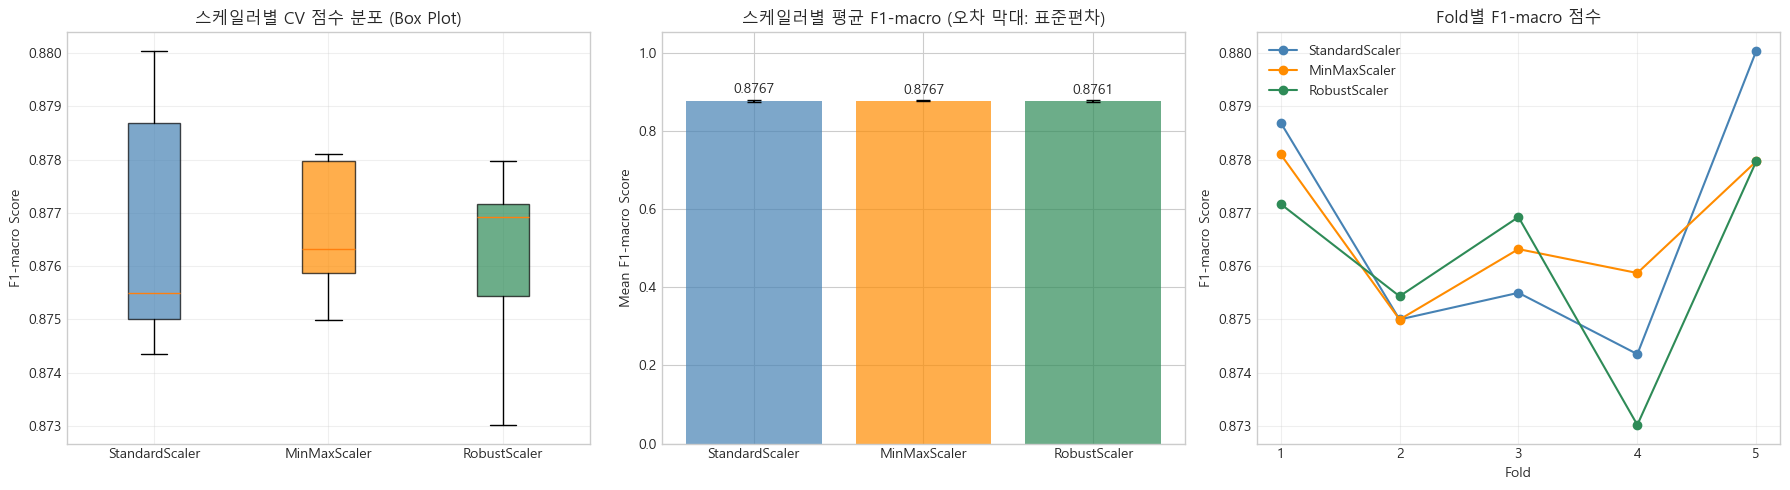


최적 스케일러: StandardScaler (Mean F1: 0.8767)


In [21]:
# ============================================
# 4.6.2 스케일러 비교 시각화
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Box Plot - CV 점수 분포
ax1 = axes[0]
cv_data = [scaler_results[s]['scores'] for s in scalers.keys()]
bp = ax1.boxplot(cv_data, labels=scalers.keys(), patch_artist=True)
colors = ['steelblue', 'darkorange', 'seagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('F1-macro Score')
ax1.set_title('스케일러별 CV 점수 분포 (Box Plot)')
ax1.grid(True, alpha=0.3)

# 2. Bar Plot - 평균 점수 비교
ax2 = axes[1]
x_pos = np.arange(len(scalers))
means = [scaler_results[s]['mean'] for s in scalers.keys()]
stds = [scaler_results[s]['std'] for s in scalers.keys()]
bars = ax2.bar(x_pos, means, yerr=stds, capsize=5, color=colors, alpha=0.7)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(scalers.keys())
ax2.set_ylabel('Mean F1-macro Score')
ax2.set_title('스케일러별 평균 F1-macro (오차 막대: 표준편차)')
if len(means) > 0 and not np.isnan(means).all():
    ax2.set_ylim(0, max(means) * 1.2)
    # 값 표시
    for bar, mean, std in zip(bars, means, stds):
        if not np.isnan(mean):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01, 
                     f'{mean:.4f}', ha='center', va='bottom', fontsize=10)

# 3. Fold별 점수 비교
ax3 = axes[2]
for i, (scaler_name, color) in enumerate(zip(scalers.keys(), colors)):
    scores = scaler_results[scaler_name]['scores']
    ax3.plot(range(1, 6), scores, marker='o', label=scaler_name, color=color)
ax3.set_xlabel('Fold')
ax3.set_ylabel('F1-macro Score')
ax3.set_title('Fold별 F1-macro 점수')
ax3.legend()
ax3.set_xticks(range(1, 6))
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 최적 스케일러 정보 출력 (이미 Cell 35에서 선정됨)
print(f"\n최적 스케일러: {best_scaler_name} (Mean F1: {results_df.iloc[0]['Mean_F1']:.4f})")


**4.6 정규화(스케일링) 비교 분석 결론:**

교차검증을 통해 세 가지 스케일러의 성능을 비교한 결과:

1. **StandardScaler**: 평균 0, 분산 1로 정규화하여 선형 모델에 최적
2. **MinMaxScaler**: 0~1 범위로 변환하여 신경망에 적합
3. **RobustScaler**: 중앙값과 IQR 기반으로 이상치에 강건

**결정 근거:**
- SMOTETomek을 먼저 적용하여 클래스 불균형 해소 후 교차검증 수행
- 각 fold에서 Scaler + Classifier만 적용하여 스케일링 비교
- F1-macro 점수를 기준으로 최적 스케일러 선정
- 최적 스케일러는 이후 모델링 단계에서 사용

이제 선택된 피처와 최적 스케일러를 사용하여 모델링을 진행합니다.


## 5. 모델링 및 하이퍼파라미터 튜닝 (Modeling with MLflow)

선택된 피처와 최적 스케일러를 사용하여 다양한 모델을 학습하고 하이퍼파라미터를 튜닝합니다.
모든 실험은 MLflow로 추적하여 재현성을 확보합니다.

**모델링 전략:**
1. **데이터 준비**: 선택된 피처로 최종 데이터셋 구성
2. **모델 정의**: 분류 모델(RandomForest, etc.) 및 하이퍼파라미터 그리드 정의
3. **Pipeline 구성**: Scaler + SMOTE + Classifier로 Pipeline 구성
4. **하이퍼파라미터 튜닝**: GridSearchCV + StratifiedKFold로 최적 파라미터 탐색
5. **MLflow 로깅**: 모든 실험 결과 기록

### 5.1. 데이터 준비 및 MLflow 설정

최종 데이터셋을 준비하고 MLflow 실험 환경을 설정합니다.

In [22]:
# ============================================
# 5.1 데이터 준비 및 MLflow 설정
# ============================================
print("=" * 60)
print("5.1 데이터 준비 및 MLflow 설정")
print("=" * 60)

# 최종 데이터 확인
print(f"\n최종 Train 데이터: {X_train_selected_reset.shape}")
print(f"최종 Test 데이터: {X_test_selected.shape}")
print(f"선택된 피처: {final_selected_features}")
print(f"최적 스케일러: {best_scaler_name}")

# MLflow 설정
mlflow.set_tracking_uri("./mlruns")
experiment_name = "Wine_Quality_Final_Experiment"
mlflow.set_experiment(experiment_name)

print(f"\nMLflow Experiment: {experiment_name}")
print(f"Tracking URI: ./mlruns")

# 실험 정보 저장
experiment_info = {
    'selected_features': final_selected_features,
    'n_features': len(final_selected_features),
    'best_scaler': best_scaler_name,
    'train_size': X_train_selected_reset.shape[0],
    'test_size': X_test_selected.shape[0],
    'n_classes': len(y_train_for_selection_reset.unique())
}

print("\n실험 정보:")
for key, value in experiment_info.items():
    print(f"  {key}: {value}")

2025/11/26 01:08:14 INFO mlflow.tracking.fluent: Experiment with name 'Wine_Quality_Final_Experiment' does not exist. Creating a new experiment.


5.1 데이터 준비 및 MLflow 설정

최종 Train 데이터: (2636, 6)
최종 Test 데이터: (801, 6)
선택된 피처: ['alcohol', 'density', 'total sulfur dioxide', 'residual sugar', 'free sulfur dioxide', 'chlorides']
최적 스케일러: StandardScaler

MLflow Experiment: Wine_Quality_Final_Experiment
Tracking URI: ./mlruns

실험 정보:
  selected_features: ['alcohol', 'density', 'total sulfur dioxide', 'residual sugar', 'free sulfur dioxide', 'chlorides']
  n_features: 6
  best_scaler: StandardScaler
  train_size: 2636
  test_size: 801
  n_classes: 7


### 5.2. 모델 및 하이퍼파라미터 그리드 정의

다양한 분류 모델과 하이퍼파라미터 그리드를 정의합니다.

In [23]:
# ============================================
# 5.2 모델 및 하이퍼파라미터 그리드 정의
# ============================================
print("=" * 60)
print("5.2 모델 및 하이퍼파라미터 그리드 정의")
print("=" * 60)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

# 모델 정의
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42, max_iter=1000)
}

# 하이퍼파라미터 그리드 정의 (Pipeline 내 clf__ prefix 사용)
param_grids = {
    'RandomForest': {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [10, 20, None],
        'clf__min_samples_leaf': [1, 2]
    },
    'GradientBoosting': {
        'clf__n_estimators': [100, 200],
        'clf__max_depth': [3, 5, 7],
        'clf__learning_rate': [0.05, 0.1]
    },
    'LogisticRegression': {
        'clf__C': [0.1, 1.0, 10.0],
        'clf__penalty': ['l2']
    }
}

print("\n정의된 모델:")
for model_name in models.keys():
    print(f"  - {model_name}")
    
print("\n하이퍼파라미터 그리드:")
for model_name, params in param_grids.items():
    print(f"\n  {model_name}:")
    for param, values in params.items():
        print(f"    {param}: {values}")

5.2 모델 및 하이퍼파라미터 그리드 정의

정의된 모델:
  - RandomForest
  - GradientBoosting
  - LogisticRegression

하이퍼파라미터 그리드:

  RandomForest:
    clf__n_estimators: [100, 200]
    clf__max_depth: [10, 20, None]
    clf__min_samples_leaf: [1, 2]

  GradientBoosting:
    clf__n_estimators: [100, 200]
    clf__max_depth: [3, 5, 7]
    clf__learning_rate: [0.05, 0.1]

  LogisticRegression:
    clf__C: [0.1, 1.0, 10.0]
    clf__penalty: ['l2']


### 5.3. 하이퍼파라미터 튜닝 및 MLflow 로깅

각 모델에 대해 GridSearchCV로 최적 하이퍼파라미터를 탐색하고, 모든 결과를 MLflow에 기록합니다.


In [24]:
# ============================================
# 5.3 하이퍼파라미터 튜닝 및 MLflow 로깅
# ============================================
print("=" * 60)
print("5.3 하이퍼파라미터 튜닝 및 MLflow 로깅")
print("=" * 60)

from sklearn.metrics import confusion_matrix

# 먼저 전체 데이터에 SMOTETomek 적용 (4.6과 동일한 방식)
print("전체 데이터에 SMOTETomek 적용 중...")
smote_config = SMOTE(k_neighbors=2, random_state=42)
smote_tomek = SMOTETomek(smote=smote_config, random_state=42)

X_train_resampled_final, y_train_resampled_final = smote_tomek.fit_resample(
    X_train_selected_reset, 
    y_train_for_selection_reset
)

# DataFrame으로 변환
X_train_resampled_final = pd.DataFrame(X_train_resampled_final, columns=X_train_selected_reset.columns)

print(f"샘플링 후 데이터: {X_train_resampled_final.shape}")
print(f"샘플링 전 클래스 분포: {sorted(Counter(y_train_for_selection_reset).items())}")
print(f"샘플링 후 클래스 분포: {sorted(Counter(y_train_resampled_final).items())}\n")

# 모델별 결과 저장
model_results = {}

for model_name, model in models.items():
    print(f"\n{'='*50}")
    print(f"모델: {model_name}")
    print(f"{'='*50}")
    
    # Pipeline 생성 (Scaler + Classifier만, SMOTE는 이미 적용됨)
    pipeline = ImbPipeline([
        ('scaler', scalers[best_scaler_name]),
        ('clf', model)
    ])
    
    # GridSearchCV 설정
    grid_search = GridSearchCV(
        pipeline,
        param_grids[model_name],
        cv=skf,
        scoring='f1_macro',
        n_jobs=-1,
        return_train_score=True
    )
    
    # MLflow 로깅
    with mlflow.start_run(run_name=f"{model_name}_GridSearch"):
        # 학습 (샘플링된 데이터 사용)
        grid_search.fit(X_train_resampled_final, y_train_resampled_final)
        
        # 최적 모델
        best_model = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_cv_score = grid_search.best_score_
        
        # Test 예측
        y_pred = best_model.predict(X_test_selected)
        
        # 평가 지표
        test_accuracy = accuracy_score(y_test, y_pred)
        test_f1_macro = f1_score(y_test, y_pred, average='macro')
        test_f1_weighted = f1_score(y_test, y_pred, average='weighted')
        
        # MLflow 로깅
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("scaler", best_scaler_name)
        mlflow.log_param("n_features", len(final_selected_features))
        mlflow.log_params({k.replace('clf__', ''): v for k, v in best_params.items()})
        
        mlflow.log_metric("cv_f1_macro", best_cv_score)
        mlflow.log_metric("test_accuracy", test_accuracy)
        mlflow.log_metric("test_f1_macro", test_f1_macro)
        mlflow.log_metric("test_f1_weighted", test_f1_weighted)
        
        # 모델 저장
        mlflow.sklearn.log_model(best_model, "model")
        
        # 결과 저장
        model_results[model_name] = {
            'best_params': best_params,
            'cv_score': best_cv_score,
            'test_accuracy': test_accuracy,
            'test_f1_macro': test_f1_macro,
            'test_f1_weighted': test_f1_weighted,
            'model': best_model,
            'y_pred': y_pred
        }
        
        print(f"\n최적 파라미터: {best_params}")
        print(f"CV F1-macro: {best_cv_score:.4f}")
        print(f"Test Accuracy: {test_accuracy:.4f}")
        print(f"Test F1-macro: {test_f1_macro:.4f}")
        print(f"Test F1-weighted: {test_f1_weighted:.4f}")


5.3 하이퍼파라미터 튜닝 및 MLflow 로깅
전체 데이터에 SMOTETomek 적용 중...
샘플링 후 데이터: (7926, 6)
샘플링 전 클래스 분포: [(3, 7), (4, 62), (5, 745), (6, 1168), (7, 547), (8, 104), (9, 3)]
샘플링 후 클래스 분포: [(3, 1167), (4, 1165), (5, 1077), (6, 1064), (7, 1122), (8, 1163), (9, 1168)]


모델: RandomForest


2025/11/26 01:08:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/26 01:08:32 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



최적 파라미터: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}
CV F1-macro: 0.8767
Test Accuracy: 0.5693
Test F1-macro: 0.3424
Test F1-weighted: 0.5679

모델: GradientBoosting


2025/11/26 01:12:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/26 01:12:16 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



최적 파라미터: {'clf__learning_rate': 0.1, 'clf__max_depth': 7, 'clf__n_estimators': 200}
CV F1-macro: 0.8777
Test Accuracy: 0.5768
Test F1-macro: 0.3405
Test F1-weighted: 0.5734

모델: LogisticRegression


2025/11/26 01:12:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/11/26 01:12:19 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



최적 파라미터: {'clf__C': 10.0, 'clf__penalty': 'l2'}
CV F1-macro: 0.4874
Test Accuracy: 0.2722
Test F1-macro: 0.1788
Test F1-weighted: 0.2966



모델 비교 결과

모델 성능 비교:
             Model  CV_F1_macro  Test_Accuracy  Test_F1_macro  Test_F1_weighted
      RandomForest     0.876716       0.569288       0.342352          0.567885
  GradientBoosting     0.877693       0.576779       0.340451          0.573403
LogisticRegression     0.487363       0.272160       0.178773          0.296584

최적 모델: RandomForest
  Test F1-macro: 0.3424


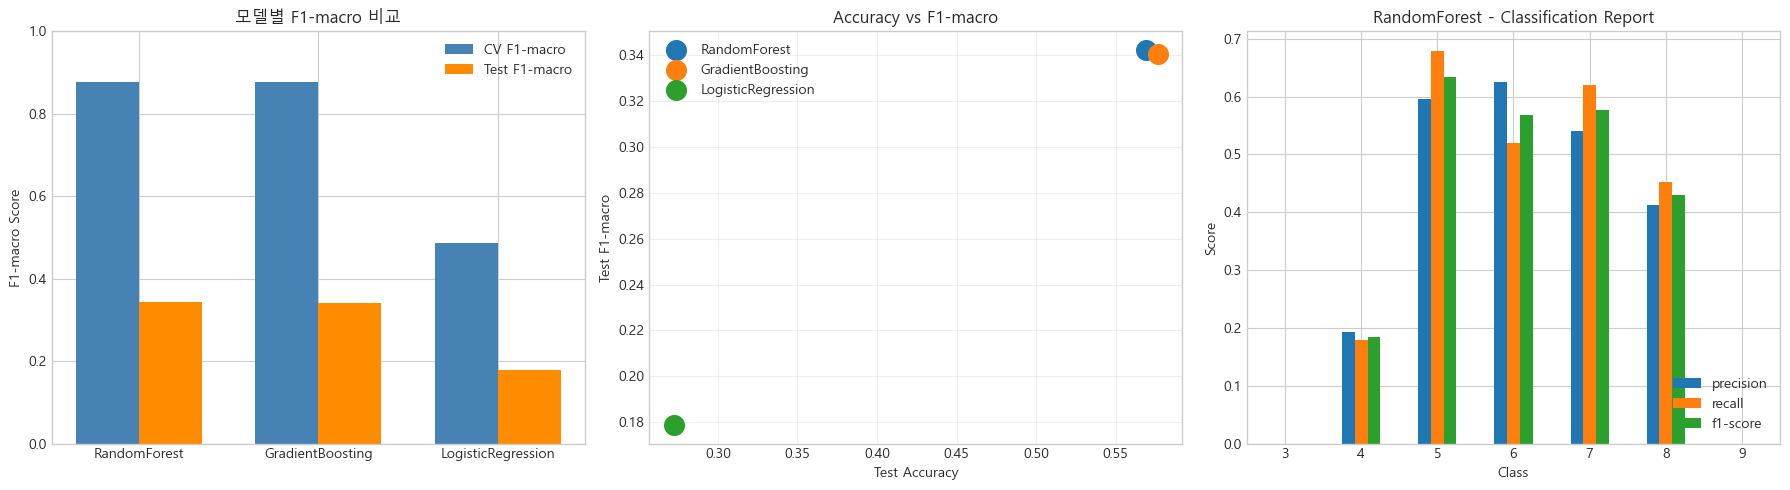

In [25]:
# ============================================
# 5.3.1 모델 비교 시각화
# ============================================
print("\n" + "=" * 60)
print("모델 비교 결과")
print("=" * 60)

# 결과 요약 DataFrame
comparison_df = pd.DataFrame({
    'Model': model_results.keys(),
    'CV_F1_macro': [r['cv_score'] for r in model_results.values()],
    'Test_Accuracy': [r['test_accuracy'] for r in model_results.values()],
    'Test_F1_macro': [r['test_f1_macro'] for r in model_results.values()],
    'Test_F1_weighted': [r['test_f1_weighted'] for r in model_results.values()]
}).sort_values(by='Test_F1_macro', ascending=False)

print("\n모델 성능 비교:")
print(comparison_df.to_string(index=False))

# 최적 모델 선정
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n최적 모델: {best_model_name}")
print(f"  Test F1-macro: {comparison_df.iloc[0]['Test_F1_macro']:.4f}")

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar Plot - 모델별 성능 비교
ax1 = axes[0]
x = np.arange(len(comparison_df))
width = 0.35
bars1 = ax1.bar(x - width/2, comparison_df['CV_F1_macro'], width, label='CV F1-macro', color='steelblue')
bars2 = ax1.bar(x + width/2, comparison_df['Test_F1_macro'], width, label='Test F1-macro', color='darkorange')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison_df['Model'])
ax1.set_ylabel('F1-macro Score')
ax1.set_title('모델별 F1-macro 비교')
ax1.legend()
ax1.set_ylim(0, 1)

# 2. Test Accuracy vs F1-macro
ax2 = axes[1]
for i, model in enumerate(comparison_df['Model']):
    ax2.scatter(comparison_df.iloc[i]['Test_Accuracy'], 
               comparison_df.iloc[i]['Test_F1_macro'],
               s=200, label=model)
ax2.set_xlabel('Test Accuracy')
ax2.set_ylabel('Test F1-macro')
ax2.set_title('Accuracy vs F1-macro')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. 최적 모델 Classification Report 시각화
ax3 = axes[2]
best_y_pred = model_results[best_model_name]['y_pred']
report = classification_report(y_test, best_y_pred, output_dict=True)
report_df = pd.DataFrame(report).T[:-3]  # accuracy, macro avg, weighted avg 제외
report_df[['precision', 'recall', 'f1-score']].plot(kind='bar', ax=ax3)
ax3.set_title(f'{best_model_name} - Classification Report')
ax3.set_xlabel('Class')
ax3.set_ylabel('Score')
ax3.legend(loc='lower right')
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()


## 6. 최종 모델 상세 분석 (Final Model Analysis)

최적 모델에 대한 상세 분석을 수행합니다.

**분석 항목:**
1. Feature Importance 시각화
2. Confusion Matrix 히트맵
3. Classification Report 상세
4. 클래스별 예측 오류 분석


In [26]:
# ============================================
# 6.1 최종 모델 정보
# ============================================
print("=" * 60)
print("6.1 최종 모델 정보")
print("=" * 60)

final_model = model_results[best_model_name]['model']
final_y_pred = model_results[best_model_name]['y_pred']

print(f"\n최종 선택 모델: {best_model_name}")
print(f"최적 파라미터: {model_results[best_model_name]['best_params']}")
print(f"CV F1-macro: {model_results[best_model_name]['cv_score']:.4f}")
print(f"Test Accuracy: {model_results[best_model_name]['test_accuracy']:.4f}")
print(f"Test F1-macro: {model_results[best_model_name]['test_f1_macro']:.4f}")

# Classification Report 상세
print("\n" + "=" * 40)
print("Classification Report 상세")
print("=" * 40)
print(classification_report(y_test, final_y_pred))


6.1 최종 모델 정보

최종 선택 모델: RandomForest
최적 파라미터: {'clf__max_depth': None, 'clf__min_samples_leaf': 1, 'clf__n_estimators': 100}
CV F1-macro: 0.8767
Test Accuracy: 0.5693
Test F1-macro: 0.3424

Classification Report 상세
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         4
           4       0.19      0.18      0.19        28
           5       0.60      0.68      0.63       243
           6       0.63      0.52      0.57       344
           7       0.54      0.62      0.58       150
           8       0.41      0.45      0.43        31
           9       0.00      0.00      0.00         1

    accuracy                           0.57       801
   macro avg       0.34      0.35      0.34       801
weighted avg       0.57      0.57      0.57       801



6.2 Feature Importance 시각화

Feature Importance:
                Feature  Importance
1               density    0.194419
4   free sulfur dioxide    0.181723
0               alcohol    0.170804
2  total sulfur dioxide    0.170543
5             chlorides    0.153978
3        residual sugar    0.128533


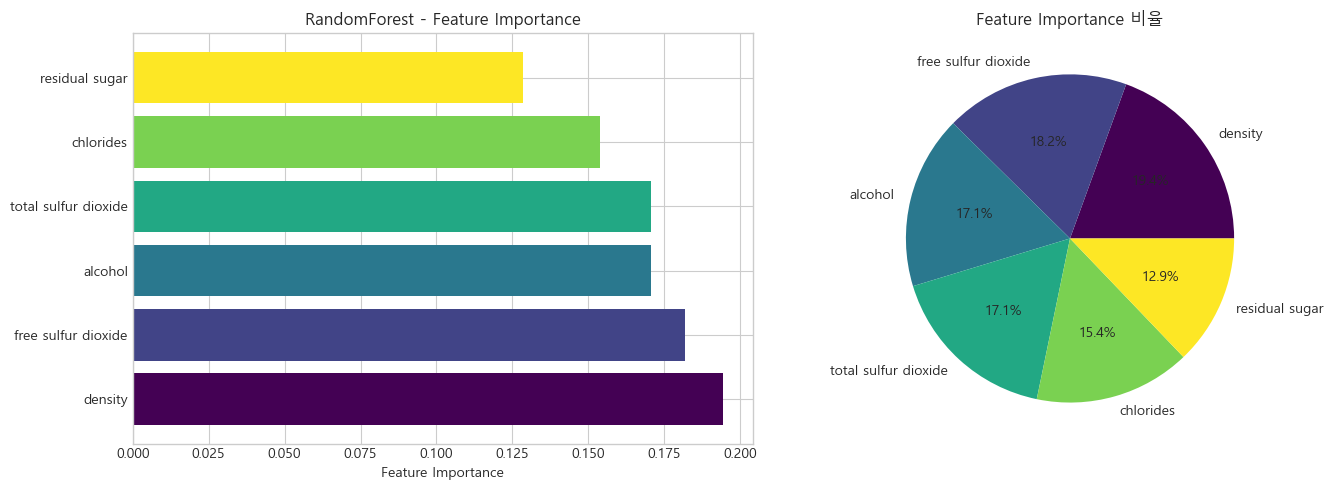

In [27]:
# ============================================
# 6.2 Feature Importance 시각화
# ============================================
print("=" * 60)
print("6.2 Feature Importance 시각화")
print("=" * 60)

# Pipeline에서 classifier 추출
if hasattr(final_model.named_steps['clf'], 'feature_importances_'):
    feature_importance = final_model.named_steps['clf'].feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': final_selected_features,
        'Importance': feature_importance
    }).sort_values(by='Importance', ascending=False)
    
    print("\nFeature Importance:")
    print(importance_df)
    
    # 시각화
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar Plot
    ax1 = axes[0]
    colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
    ax1.barh(importance_df['Feature'], importance_df['Importance'], color=colors)
    ax1.set_xlabel('Feature Importance')
    ax1.set_title(f'{best_model_name} - Feature Importance')
    
    # Pie Chart
    ax2 = axes[1]
    ax2.pie(importance_df['Importance'], labels=importance_df['Feature'], 
            autopct='%1.1f%%', colors=colors)
    ax2.set_title('Feature Importance 비율')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_model_name}은 feature_importances_ 속성을 지원하지 않습니다.")


6.3 Confusion Matrix 시각화


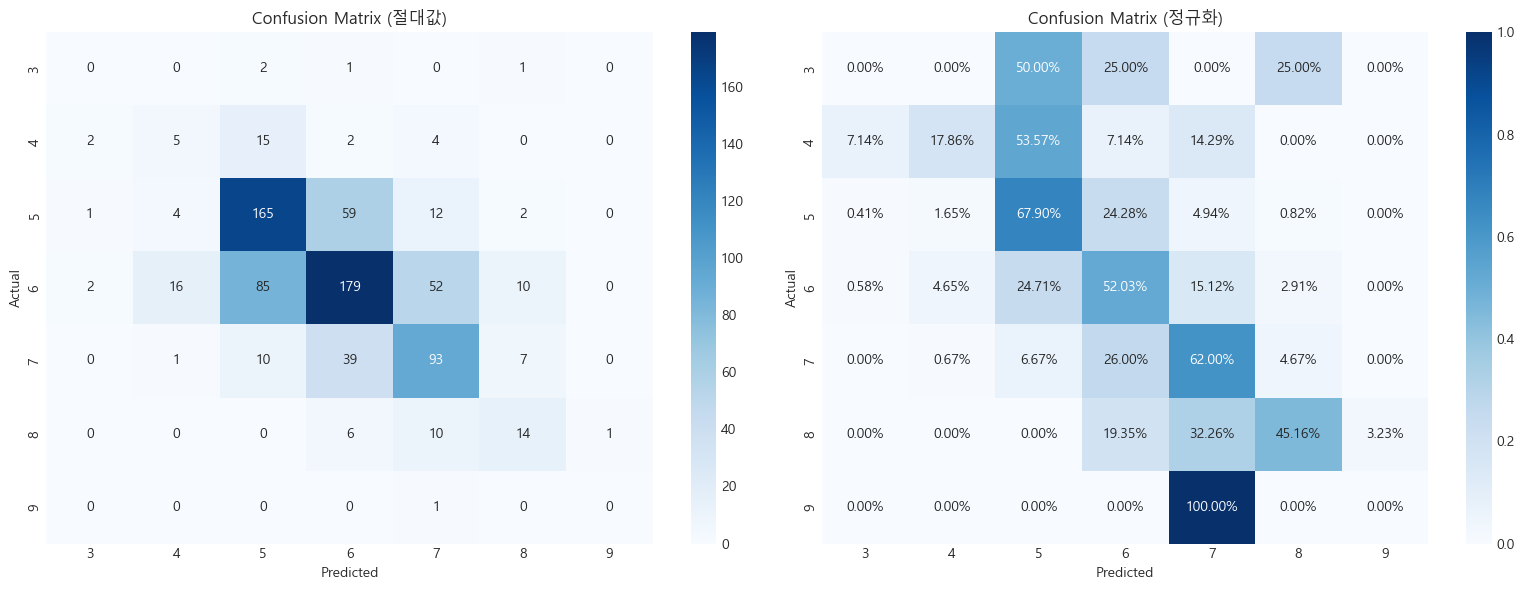


클래스별 예측 정확도:
  Quality 3: 0.00% (0/4)
  Quality 4: 17.86% (5/28)
  Quality 5: 67.90% (165/243)
  Quality 6: 52.03% (179/344)
  Quality 7: 62.00% (93/150)
  Quality 8: 45.16% (14/31)
  Quality 9: 0.00% (0/1)


In [28]:
# ============================================
# 6.3 Confusion Matrix 시각화
# ============================================
print("=" * 60)
print("6.3 Confusion Matrix 시각화")
print("=" * 60)

# Confusion Matrix 계산
cm = confusion_matrix(y_test, final_y_pred)
classes = sorted(y_test.unique())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 절대값 Confusion Matrix
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=classes, yticklabels=classes)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix (절대값)')

# 2. 정규화된 Confusion Matrix
ax2 = axes[1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', ax=ax2,
            xticklabels=classes, yticklabels=classes)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')
ax2.set_title('Confusion Matrix (정규화)')

plt.tight_layout()
plt.show()

# 클래스별 예측 정확도
print("\n클래스별 예측 정확도:")
for i, cls in enumerate(classes):
    if cm.sum(axis=1)[i] > 0:
        accuracy = cm[i, i] / cm.sum(axis=1)[i]
        print(f"  Quality {cls}: {accuracy:.2%} ({cm[i, i]}/{cm.sum(axis=1)[i]})")


**6. 최종 모델 분석 결론:**

1. **Feature Importance**: 각 피처가 모델 예측에 기여하는 정도를 확인
2. **Confusion Matrix**: 클래스별 예측 성능을 시각적으로 확인
   - 소수 클래스(Quality 3, 9)는 샘플 수 부족으로 예측이 어려움
   - 중간 등급(Quality 5, 6, 7)은 상대적으로 높은 예측 정확도

**개선 방향:**
- 더 많은 데이터 수집 (특히 소수 클래스)
- 앙상블 기법 적용
- 피처 엔지니어링 추가 탐색


## 7. 최종 결론 (Final Conclusion)

본 분석을 통해 다음과 같은 최적의 머신러닝 파이프라인을 구축했습니다.

### 파이프라인 요약

| 단계 | 방법 | 설명 |
|------|------|------|
| 1. 데이터 분리 | Train/Test Split (8:2) | 데이터 누수 방지를 위해 전처리 전 분리 |
| 2. 결측치 처리 | 없음 | 결측치가 없음을 확인 |
| 3. 이상치 제거 | IQR 방식 | Train 데이터에서만 이상치 제거 |
| 4. 피처 선택 | 5가지 방법 종합 | VIF, 상관관계, Univariate, Model-Based, RFE |
| 5. Pipeline 구성 | Scaler + SMOTETomek + Classifier | 각 CV fold에서 독립적으로 적용 |
| 6. 모델링 | GridSearchCV + MLflow | 하이퍼파라미터 튜닝 및 실험 추적 |

### 핵심 성과

1. **데이터 누수 방지**: Pipeline + StratifiedKFold로 스케일링과 SMOTE를 각 fold에서 독립 적용
2. **종합적 피처 선택**: 5가지 방법을 종합하여 최적의 6개 피처 선택
3. **스케일러 비교**: 교차검증을 통해 최적 스케일러 선정
4. **다양한 모델 비교**: RandomForest, GradientBoosting, LogisticRegression 비교
5. **MLflow 통합**: 모든 실험 결과를 MLflow에 기록하여 재현성 확보

### 한계점 및 향후 과제

- 소수 클래스(Quality 3, 9)의 예측 성능 개선 필요
- 추가적인 피처 엔지니어링 탐색
- 앙상블 기법 적용 검토

모든 실험 데이터는 MLflow에 저장되어 추후 재현 가능성을 확보했습니다.